# speMCA - poison Dataset

In [1]:
# disable warnings
from warnings import simplefilter, filterwarnings
simplefilter(action='ignore', category=FutureWarning)
filterwarnings("ignore")

## poison dataset

In [2]:
#poison dataset
from scientisttools.datasets import poison
poison._fields

('actif', 'sup_var', 'data', 'group', 'name')

In [3]:
# overall dataset
data = poison.data

## Instanciation and training

In [4]:
# instanciation
from scientisttools import MCA
clf = MCA(excl=(0,2),sup_var=(0,1,8,9,10,11,12,13,14))

### `fit` function

In [5]:
# fit function
clf.fit(data)

,excl,"(0, ...)"
,sup_var,"(0, ...)"
,iv,None
,ortho,False
,group,None
,option,'between'
,ncp,5
,row_w,None
,col_w,None
,excl_sup,None
,ind_sup,None


### `fit_transform` function

In [6]:
# fit_transform function - individuals coordinates
ind_coord = clf.fit_transform(data)
ind_coord

,Dim1,Dim2,Dim3,Dim4,Dim5
1,0.484794,0.748430,-0.360138,-0.250561,-0.038621
2,-0.945158,0.058608,0.054613,-0.297039,-0.028981
3,0.520466,-0.452307,0.113383,-0.298187,-0.012935
4,-0.945158,0.058608,0.054613,-0.297039,-0.028981
5,0.520315,-0.445161,0.188531,0.279325,-0.016656
6,0.175617,-0.154505,-0.505300,0.367074,0.013944
7,0.520466,-0.452307,0.113383,-0.298187,-0.012935
8,0.829492,0.457774,0.333692,-0.338309,-0.069221
9,0.484642,0.755576,-0.284990,0.326951,-0.042342
10,0.025405,-0.378185,0.449046,0.250123,-0.592862


### `transform` function

In [7]:
# transform function 6 individuals coordinates
ind_coord = clf.transform(data.iloc[:,2:8])
ind_coord

,Dim1,Dim2,Dim3,Dim4,Dim5
1,0.484794,0.748430,-0.360138,-0.250561,-0.038621
2,-0.945158,0.058608,0.054613,-0.297039,-0.028981
3,0.520466,-0.452307,0.113383,-0.298187,-0.012935
4,-0.945158,0.058608,0.054613,-0.297039,-0.028981
5,0.520315,-0.445161,0.188531,0.279325,-0.016656
6,0.175617,-0.154505,-0.505300,0.367074,0.013944
7,0.520466,-0.452307,0.113383,-0.298187,-0.012935
8,0.829492,0.457774,0.333692,-0.338309,-0.069221
9,0.484642,0.755576,-0.284990,0.326951,-0.042342
10,0.025405,-0.378185,0.449046,0.250123,-0.592862


## Eigen values

In [8]:
# eigenvalues
from scientisttools import get_eig
eig = get_eig(clf)
eig

,Eigenvalue,Difference,Proportion (%),Cumulative (%),modified rates,cumulative modified rates
Dim1,0.446180,0.307403,55.562017,55.562017,100.0,100.0
Dim2,0.138777,0.034239,17.281623,72.843639,0.0,100.0
Dim3,0.104537,0.019960,13.017849,85.861488,0.0,100.0
Dim4,0.084577,0.057936,10.532235,96.393723,0.0,100.0
Dim5,0.026641,0.024323,3.317591,99.711314,0.0,100.0
Dim6,0.002318,NaN,0.288686,100.000000,0.0,100.0


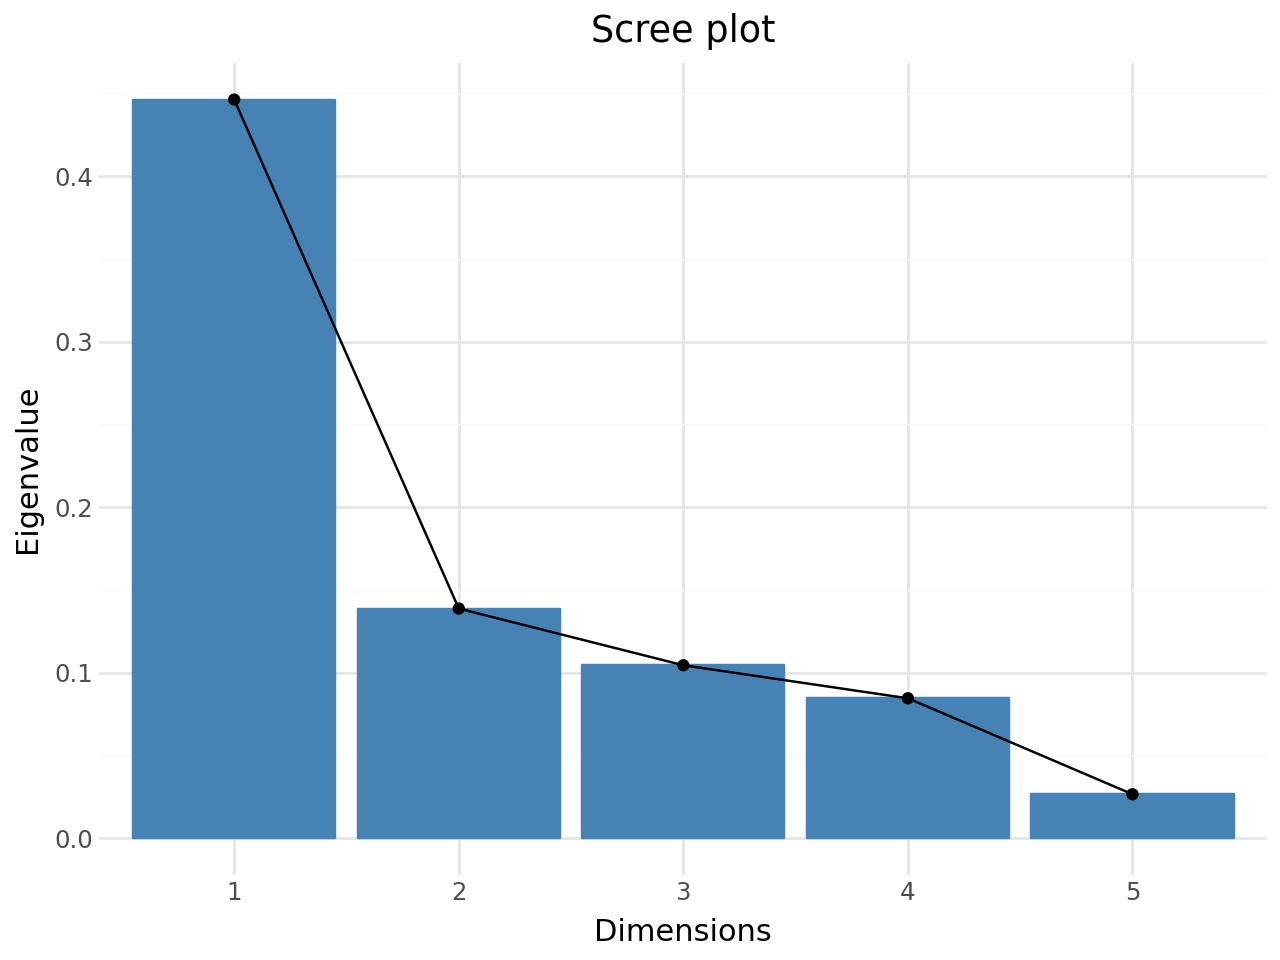

None


In [9]:
# scree plot - eigenvalue
from scientisttools import fviz_screeplot
p = fviz_screeplot(obj=clf,choice="eigenvalue")
print(p.show())

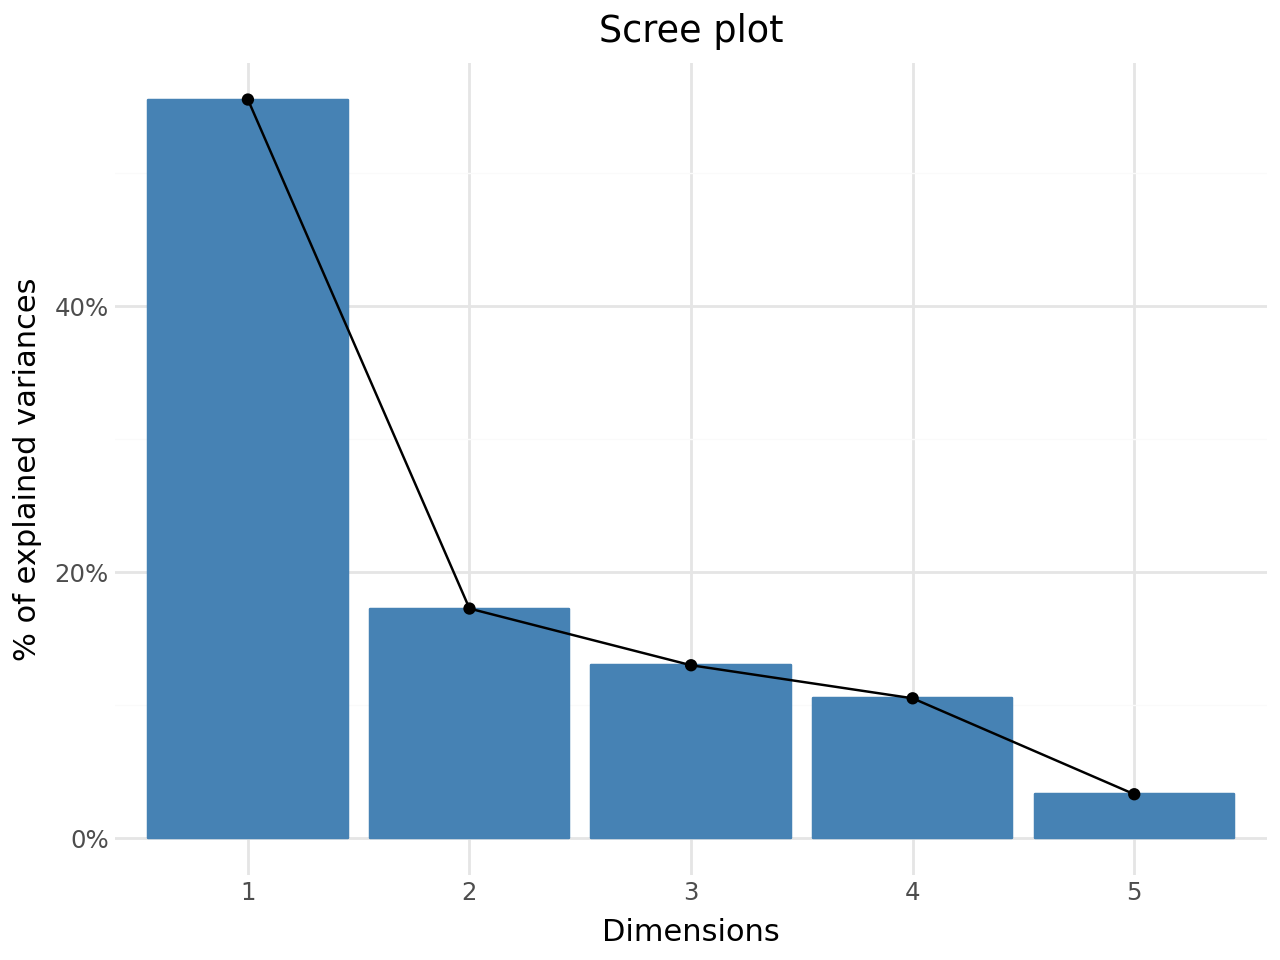

None


In [10]:
# scree plot - proportion
p = fviz_screeplot(obj=clf,choice="proportion")
print(p.show())

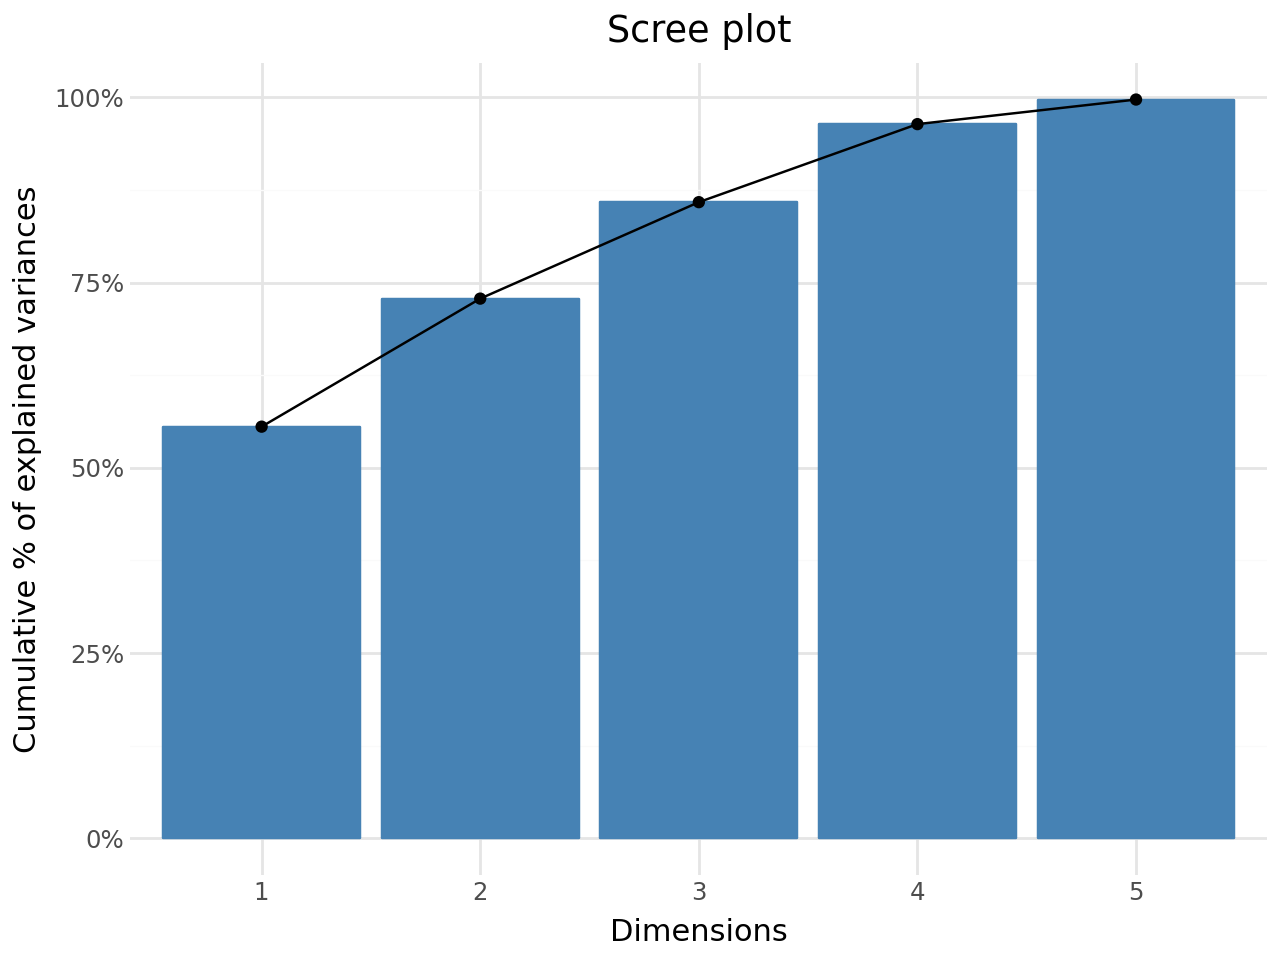

None


In [11]:
# scree plot - cumulative
p = fviz_screeplot(obj=clf,choice="cumulative")
print(p.show())

## Individuals informations

In [12]:
# individuals informations
from scientisttools import get_mca
ind = get_mca(clf)
ind._fields

('coord', 'cos2', 'contrib', 'infos')

### Individuals factor coordinates

In [13]:
# individuals factor coordinates
ind.coord

,Dim1,Dim2,Dim3,Dim4,Dim5
1,0.484794,0.748430,-0.360138,-0.250561,-0.038621
2,-0.945158,0.058608,0.054613,-0.297039,-0.028981
3,0.520466,-0.452307,0.113383,-0.298187,-0.012935
4,-0.945158,0.058608,0.054613,-0.297039,-0.028981
5,0.520315,-0.445161,0.188531,0.279325,-0.016656
6,0.175617,-0.154505,-0.505300,0.367074,0.013944
7,0.520466,-0.452307,0.113383,-0.298187,-0.012935
8,0.829492,0.457774,0.333692,-0.338309,-0.069221
9,0.484642,0.755576,-0.284990,0.326951,-0.042342
10,0.025405,-0.378185,0.449046,0.250123,-0.592862


41 [0.01157131 0.52756263]
46 [ 0.8558009  -0.23559067]
47 [ 0.01637581 -0.07915234]
21 [-0.49328256  0.36282323]
24 [ 0.15520806 -0.20559167]
30 [ 0.75522154 -0.32916521]
27 [-0.15608041 -0.06428819]
44 [-0.63236609  0.80741603]
53 [-0.95920506  0.29577596]
54 [0.49273728 0.65185766]
18 [-0.97962602 -0.19804297]
22 [-0.86228838 -0.72322607]
26 [-0.91399671 -0.52296974]
35 [0.32218329 0.86937976]
39 [ 0.98372012 -0.98314444]
7 [ 0.67794409 -0.09392171]
10 [-0.18402677  0.58104001]


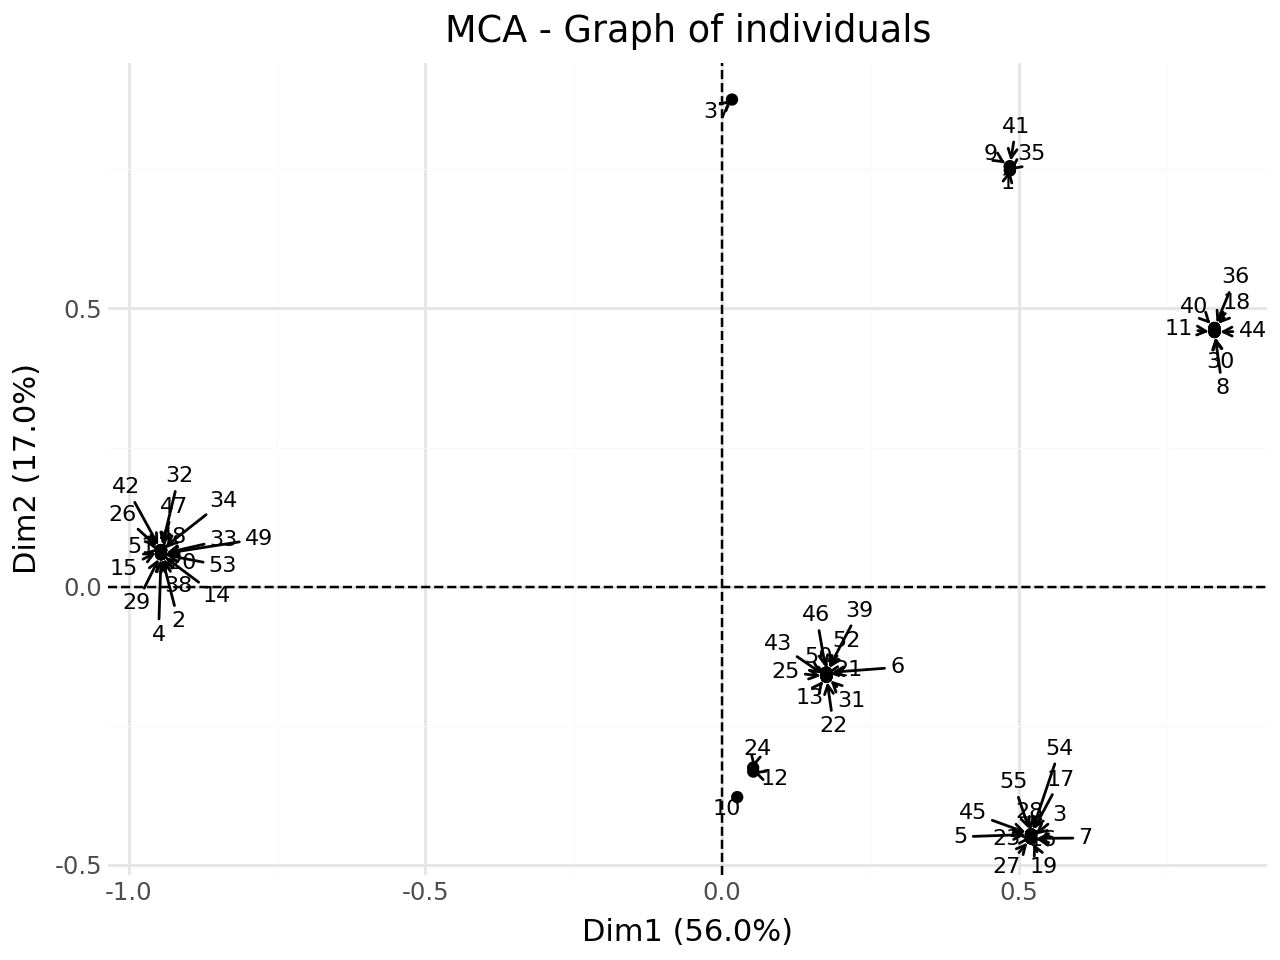

None


In [14]:
# graph of individuals
from scientisttools import fviz_mca
p = fviz_mca(
    obj=clf,
    choice="ind",
    repel = True,
    ind_sup = False
)
print(p.show())

#### individuals cos2

In [15]:
# individuals cos2
ind.cos2

,Dim1,Dim2,Dim3,Dim4,Dim5
1,0.237515,0.566082,0.131074,0.063446,0.001507
2,0.903395,0.003474,0.003016,0.089227,0.000849
3,0.468907,0.354134,0.022253,0.153914,0.000290
4,0.903395,0.003474,0.003016,0.089227,0.000849
5,0.463679,0.339407,0.060876,0.133630,0.000475
6,0.069309,0.053647,0.573798,0.302808,0.000437
7,0.468907,0.354134,0.022253,0.153914,0.000290
8,0.609760,0.185711,0.098680,0.101429,0.004246
9,0.235895,0.573366,0.081571,0.107360,0.001801
10,0.000763,0.169183,0.238523,0.074004,0.415772


41 [ 0.52609745 -0.78404939]
46 [0.92829792 0.22617643]
47 [ 0.39514577 -0.50024205]
21 [-0.97262725 -0.30568203]
24 [-0.98962508 -0.74420331]
30 [0.80115609 0.99646921]
27 [-0.75099944  0.16627137]
44 [-0.36139965 -0.47224849]
53 [0.03027395 0.48286208]
54 [-0.60090011 -0.31006399]
18 [0.74387802 0.67265863]
22 [0.51291769 0.93867567]
26 [0.3134579  0.83315305]
35 [-0.84304175  0.49294491]
39 [ 0.27045125 -0.57148527]
7 [ 0.77012504 -0.1915276 ]
10 [-0.61306171  0.81844627]
15 [-0.86277396 -0.39213085]
18 [-0.47134966  0.51172966]
33 [0.97839538 0.75125831]
46 [-0.54999134  0.57338335]


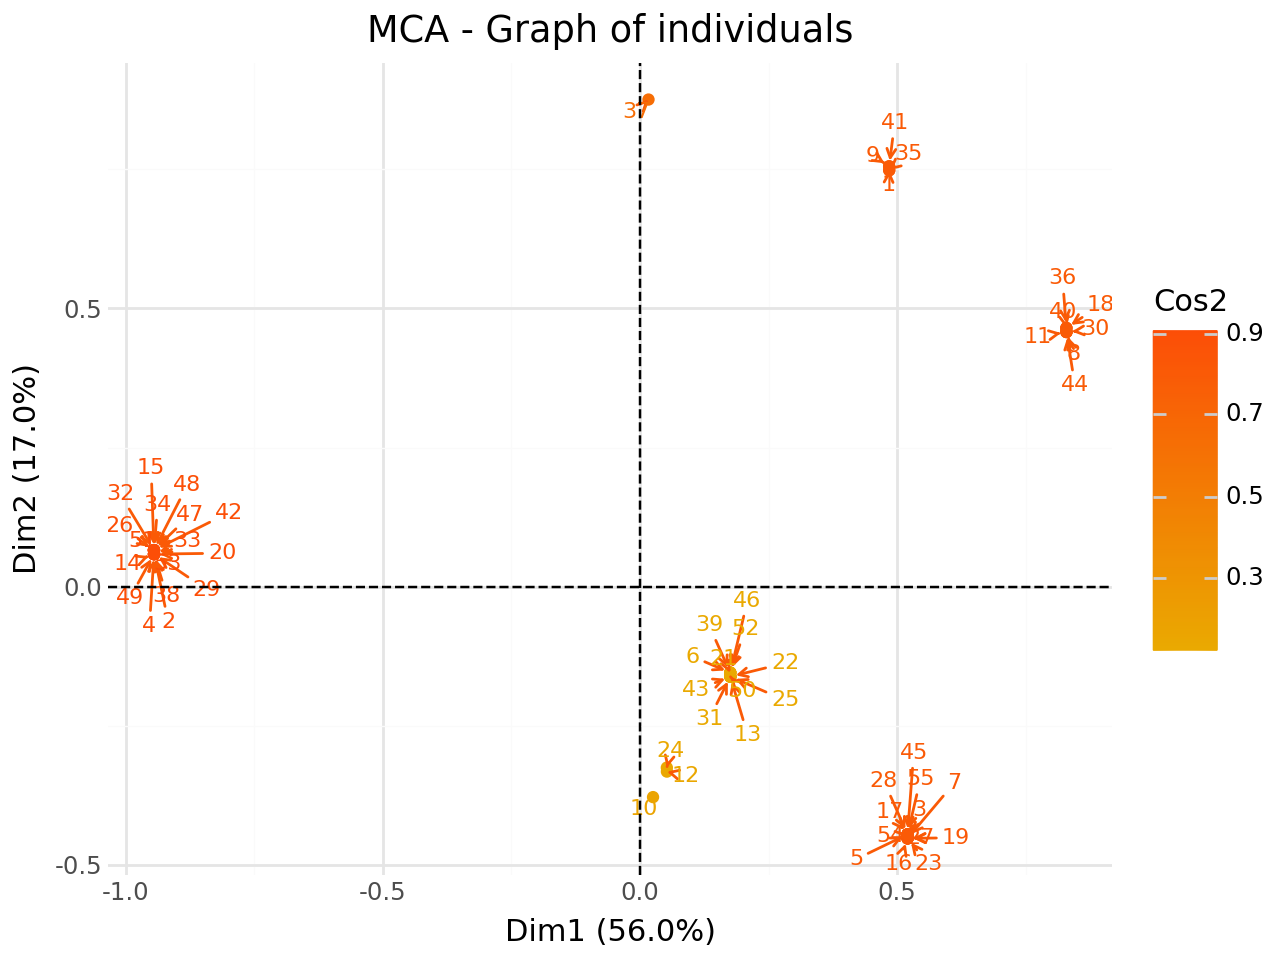

None


In [16]:
# graph of individuals - color by cosinus
p = fviz_mca(
    obj=clf,
    choice="ind",
    col_ind="cos2",
    repel=True,
    ind_sup=False
)
print(p.show())

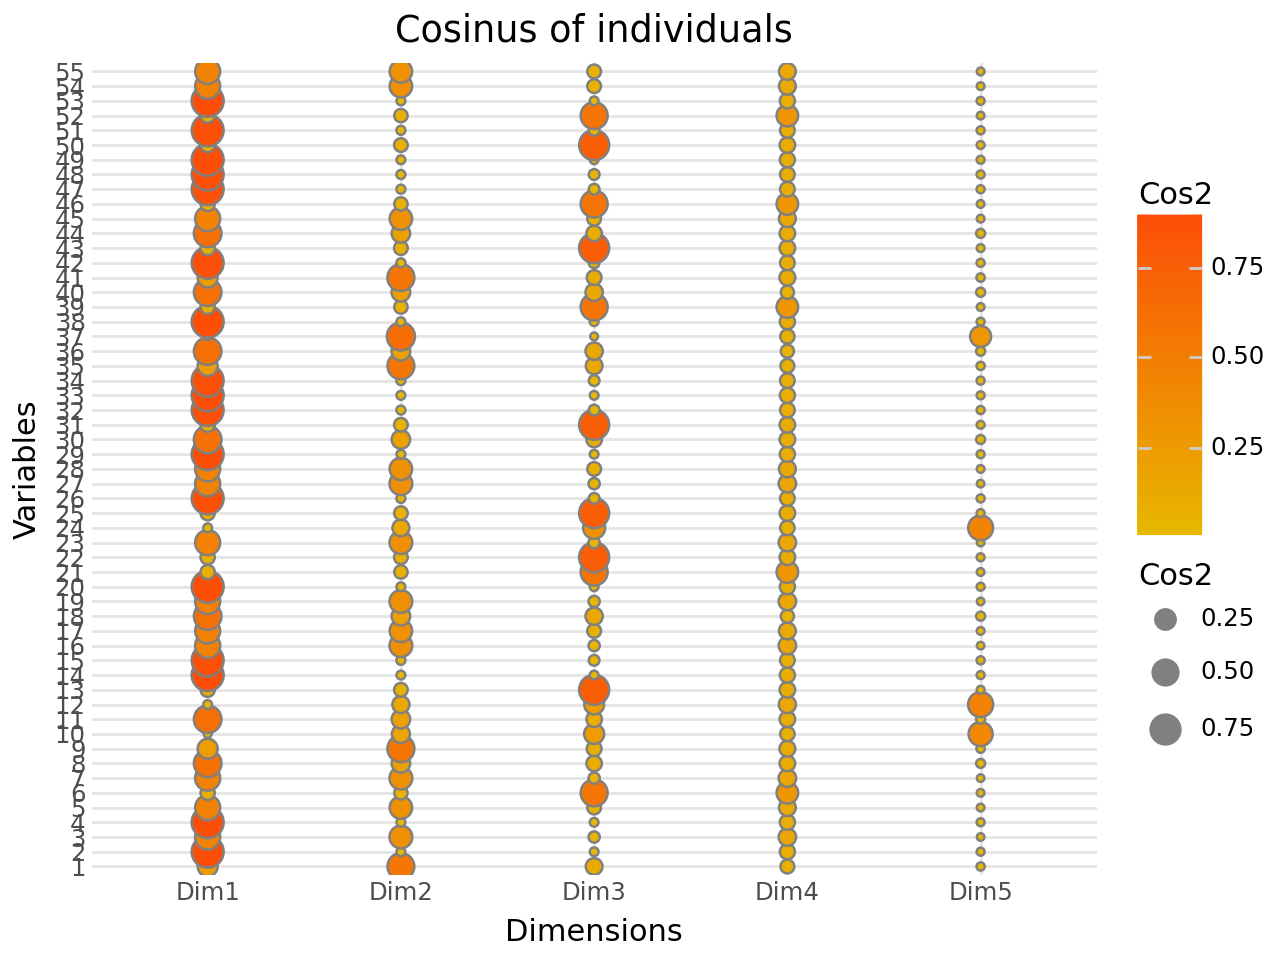

None


In [17]:
# graph of cosinus
from scientisttools import fviz_corrplot
p = fviz_corrplot(
    X=ind.cos2,
    legend_title="Cos2",
    title="Cosinus of individuals"
)
print(p.show())

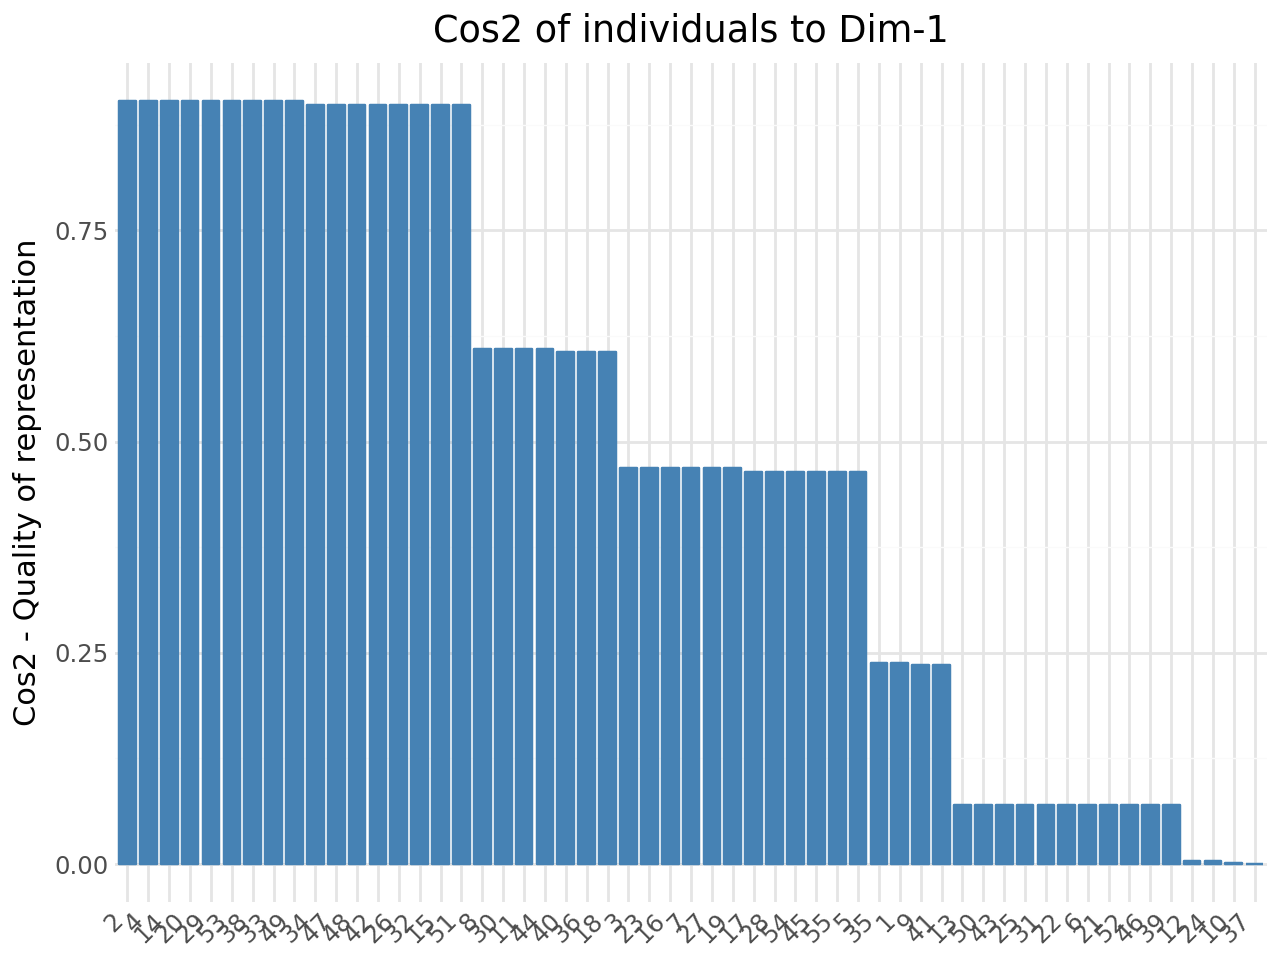

None


In [18]:
# cosinus of individuals to axis 1
from scientisttools import fviz_cos2
p = fviz_cos2(
    obj=clf,
    choice="ind"
)
print(p.show())

### Individuals contributions

In [19]:
# individuals contributions
ind.contrib

,Dim1,Dim2,Dim3,Dim4,Dim5
1,0.957727,7.338774,2.255823,1.349616,0.101798
2,3.640291,0.045002,0.051874,1.896756,0.057321
3,1.103857,2.680322,0.223594,1.911446,0.011418
4,3.640291,0.045002,0.051874,1.896756,0.057321
5,1.103214,2.596306,0.618202,1.677276,0.018932
6,0.125678,0.312757,4.440839,2.896623,0.013270
7,1.103857,2.680322,0.223594,1.911446,0.011418
8,2.803830,2.745510,1.936685,2.460442,0.327011
9,0.957129,7.479570,1.412624,2.298007,0.122357
10,0.002630,1.873829,3.507104,1.344909,23.987745


41 [0.63210769 0.44837291]
46 [-0.61394508  0.78757102]
47 [ 0.30671627 -0.46703649]
21 [0.27839256 0.15607692]
24 [ 0.4453343  -0.32071614]
30 [ 0.28917003 -0.06445143]
27 [0.14983188 0.04966808]
44 [0.04707793 0.20986846]
53 [0.95871445 0.19974616]
54 [-0.34273814 -0.42415336]
18 [0.36769678 0.00017773]
22 [-0.593955    0.09397474]
26 [0.17383711 0.27435398]
35 [0.73401825 0.4903874 ]
39 [0.61968085 0.18563799]
7 [-0.24514199  0.22971704]
10 [ 0.25077294 -0.0595228 ]
6 [-0.30651473  0.27825391]
22 [0.13649544 0.31344559]


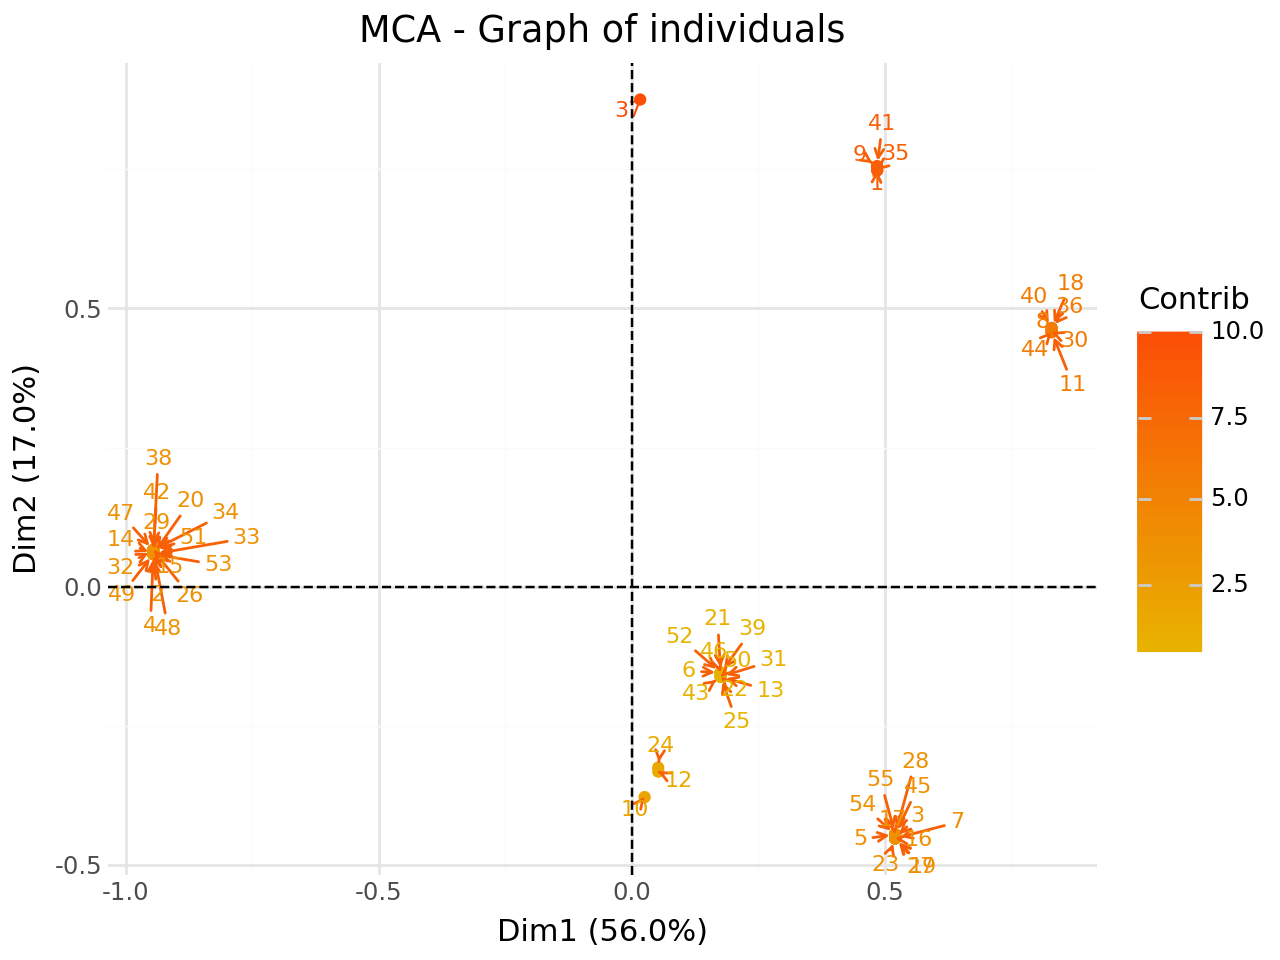

None


In [20]:
# graph of individuals - color by contributions
p = fviz_mca(
    obj=clf,
    choice="ind",
    col_ind="contrib",
    repel=True,
    ind_sup=False
)
print(p.show())

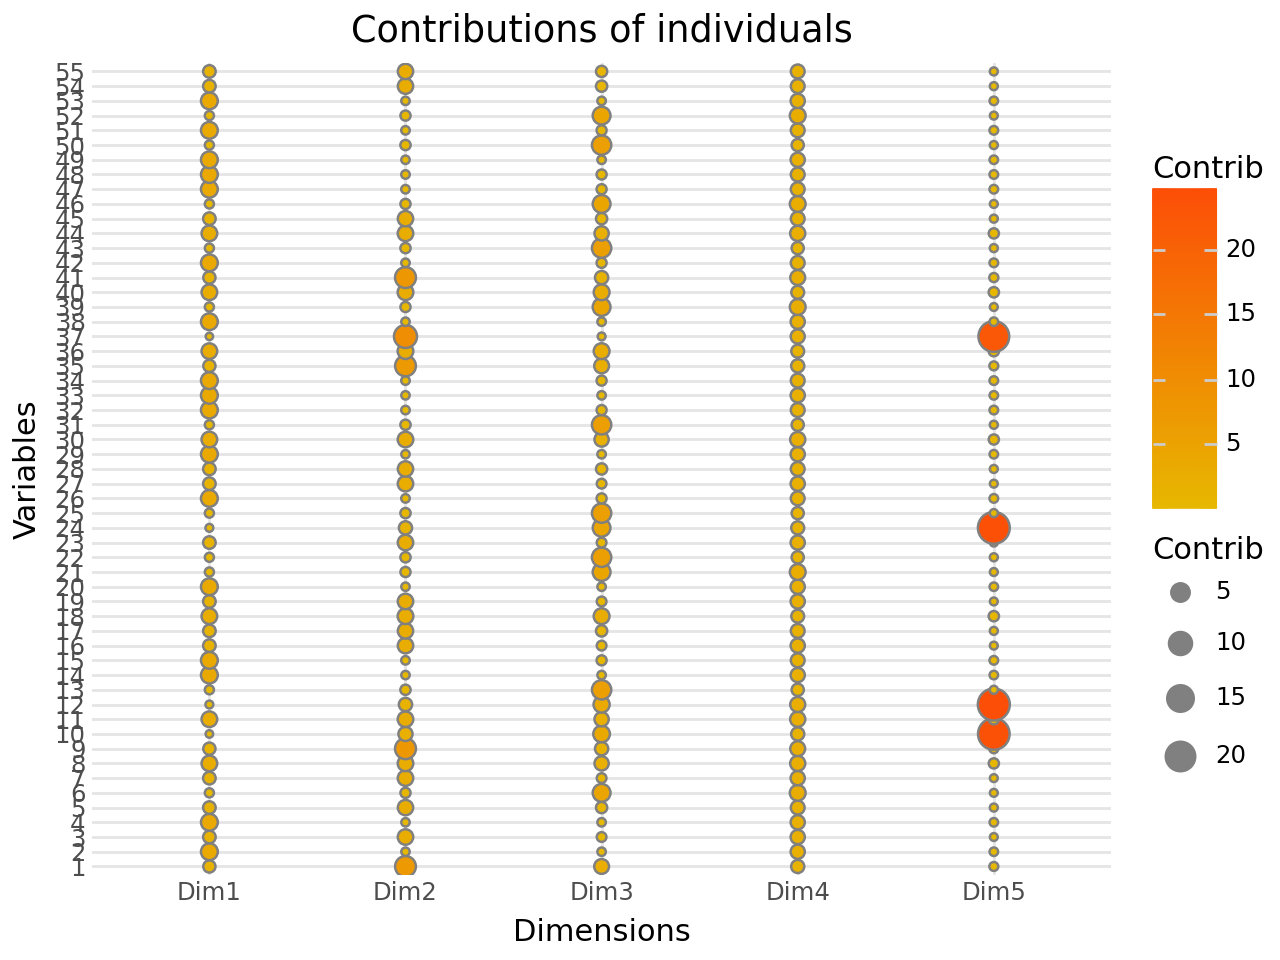

None


In [21]:
# graph 
p = fviz_corrplot(
    X=ind.contrib,
    legend_title="Contrib",
    title="Contributions of individuals"
)
print(p.show())

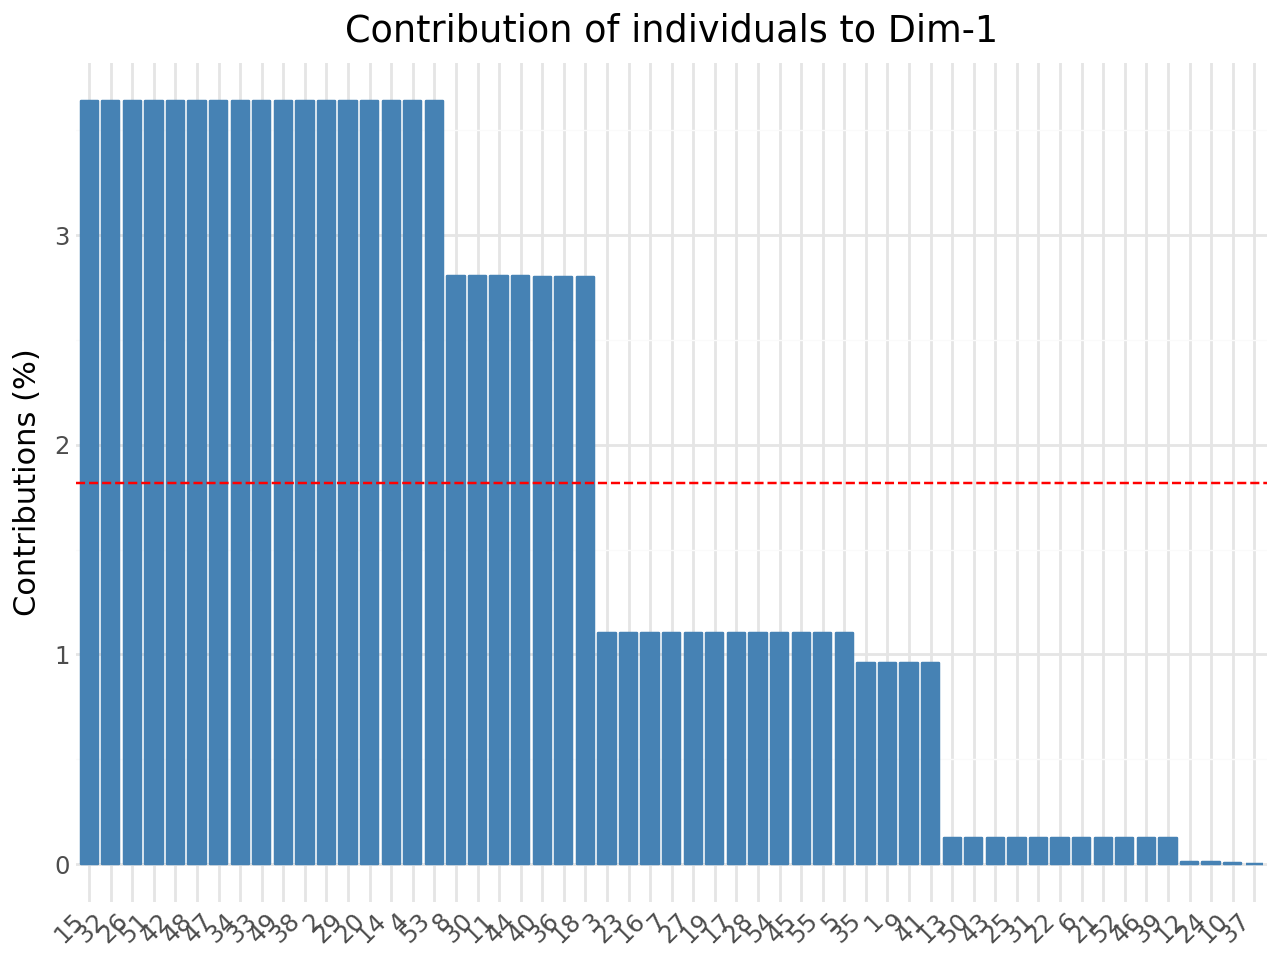

None


In [22]:
# contributions of individuals to axis 1
from scientisttools import fviz_contrib
p = fviz_contrib(
    obj=clf,
    choice="ind"
)
print(p.show())

### Individuals additionals informations

In [23]:
# individuals additionals informations
ind.infos

,Weight,Sq. Dist.,Inertia,Inertia (%)
1,0.018182,0.989517,0.017991,2.240416
2,0.018182,0.988852,0.017979,2.238909
3,0.018182,0.577695,0.010504,1.307989
4,0.018182,0.988852,0.017979,2.238909
5,0.018182,0.583868,0.010616,1.321965
6,0.018182,0.444979,0.008091,1.007500
7,0.018182,0.577695,0.010504,1.307989
8,0.018182,1.128406,0.020516,2.554881
9,0.018182,0.995690,0.018103,2.254392
10,0.018182,0.845380,0.015371,1.914067


## Levels informations

In [24]:
# levels informations
levels = clf.levels_
levels._fields

('coord', 'cos2', 'contrib', 'infos', 'coord_n', 'vtest')

### Levels coordinates - Quasi barycenters

In [25]:
# levels coordinates - quasi barycenters
levels.coord

,Dim1,Dim2,Dim3,Dim4,Dim5
Sick_y,0.633064,-0.074420,-0.124497,0.038870,0.084233
M,-0.000607,0.015971,0.145782,1.007717,-0.003644
Nausea_n,-0.270221,-0.443821,-0.093248,0.015275,0.012027
Nausea_y,0.968292,1.590359,0.334138,-0.054736,-0.043096
Vomit_n,-0.552592,0.259866,-0.538394,0.061246,0.011987
Vomit_y,0.828889,-0.389799,0.807591,-0.091869,-0.017980
Abdo_n,-1.334355,0.100709,0.339985,-0.034279,-0.379617
Abdo_y,0.649146,-0.048994,-0.165398,0.016676,0.184678
Fever_n,-1.193745,0.170666,0.383152,-0.039001,0.383629
Fever_y,0.682140,-0.097524,-0.218944,0.022286,-0.219217


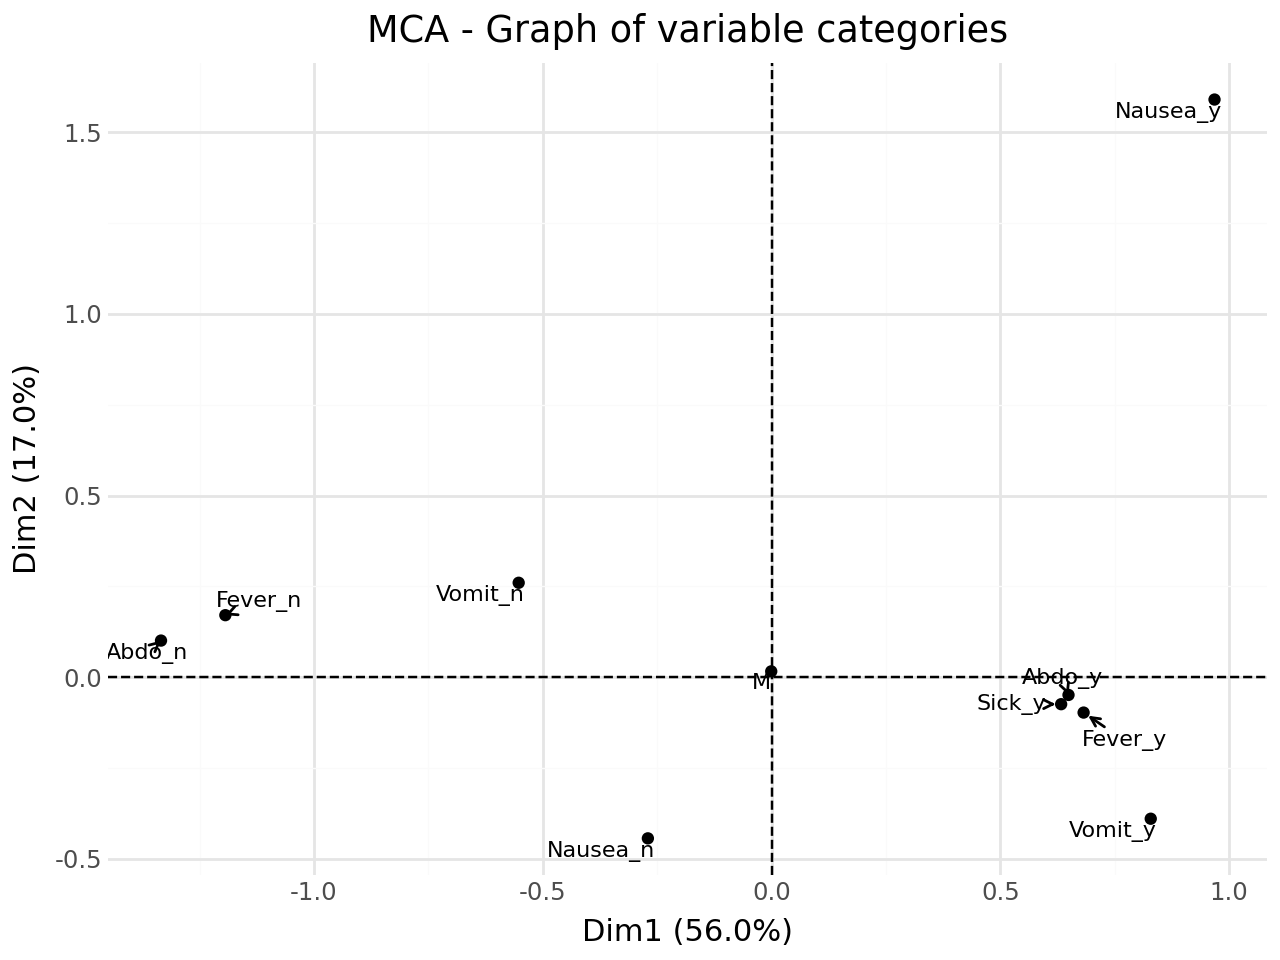

None


In [26]:
# graph of variable categories
p = fviz_mca(
    obj=clf,
    choice="levels",
    repel = True,
    quali_sup = False
)
print(p.show())

### Levels of coordinates - barycenters

In [27]:
# levels coordinates - quasi barycenters
levels.coord_n

,Dim1,Dim2,Dim3,Dim4,Dim5
Sick_y,0.422866,-0.027723,-0.040253,0.011304,0.013749
M,-0.000406,0.005950,0.047135,0.293066,-0.000595
Nausea_n,-0.180499,-0.165336,-0.030149,0.004442,0.001963
Nausea_y,0.646787,0.592452,0.108034,-0.015918,-0.007034
Vomit_n,-0.369114,0.096807,-0.174075,0.017812,0.001957
Vomit_y,0.553670,-0.145211,0.261112,-0.026718,-0.002935
Abdo_n,-0.891305,0.037517,0.109925,-0.009969,-0.061962
Abdo_y,0.433608,-0.018251,-0.053477,0.004850,0.030144
Fever_n,-0.797382,0.063578,0.123881,-0.011342,0.062617
Fever_y,0.455647,-0.036330,-0.070789,0.006481,-0.035781


### Levels vtest

In [28]:
# levels vtest
levels.vtest

,Dim1,Dim2,Dim3,Dim4,Dim5
Sick_y,6.955234,-0.817623,-1.367800,0.427055,0.925435
M,-0.004381,0.115247,1.051971,7.271738,-0.026295
Nausea_n,-3.758891,-6.173741,-1.297118,0.212483,0.167299
Nausea_y,3.758891,6.173741,1.297118,-0.212483,-0.167299
Vomit_n,-4.973332,2.338792,-4.845548,0.551216,0.107883
Vomit_y,4.973332,-2.338792,4.845548,-0.551216,-0.107883
Abdo_n,-6.839175,0.516181,1.742578,-0.175695,-1.945709
Abdo_y,6.839175,-0.516181,-1.742578,0.175695,1.945709
Fever_n,-6.631161,0.948038,2.128377,-0.216646,2.131031
Fever_y,6.631161,-0.948038,-2.128377,0.216646,-2.131031


### Levels cos2

In [29]:
# levels cos2
levels.cos2

,Dim1,Dim2,Dim3,Dim4,Dim5
Sick_y,8.958384e-01,0.012380,0.034646,0.003377,0.015860
M,3.554954e-07,0.000246,0.020493,0.979225,0.000013
Nausea_n,2.616530e-01,0.705835,0.031158,0.000836,0.000518
Nausea_y,2.616530e-01,0.705835,0.031158,0.000836,0.000518
Vomit_n,4.580377e-01,0.101295,0.434803,0.005627,0.000216
Vomit_y,4.580377e-01,0.101295,0.434803,0.005627,0.000216
Abdo_n,8.661910e-01,0.004934,0.056233,0.000572,0.070107
Abdo_y,8.661910e-01,0.004934,0.056233,0.000572,0.070107
Fever_n,8.143017e-01,0.016644,0.083889,0.000869,0.084098
Fever_y,8.143017e-01,0.016644,0.083889,0.000869,0.084098


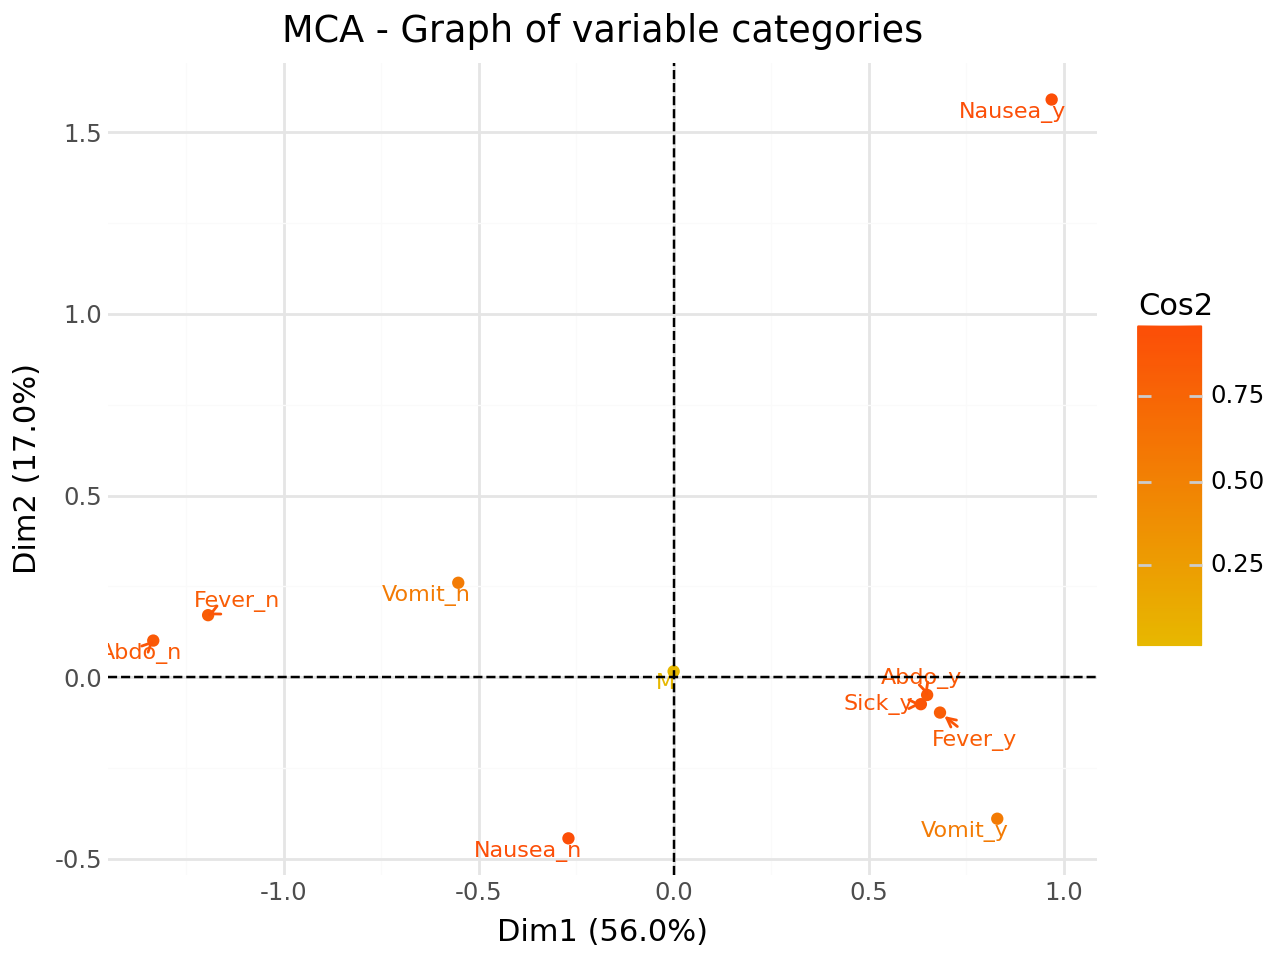

None


In [30]:
# graph of variable categories - color by cos2
p = fviz_mca(
    obj=clf,
    choice="levels",
    col_var = "cos2",
    repel = True,
    quali_sup = False
)
print(p.show())

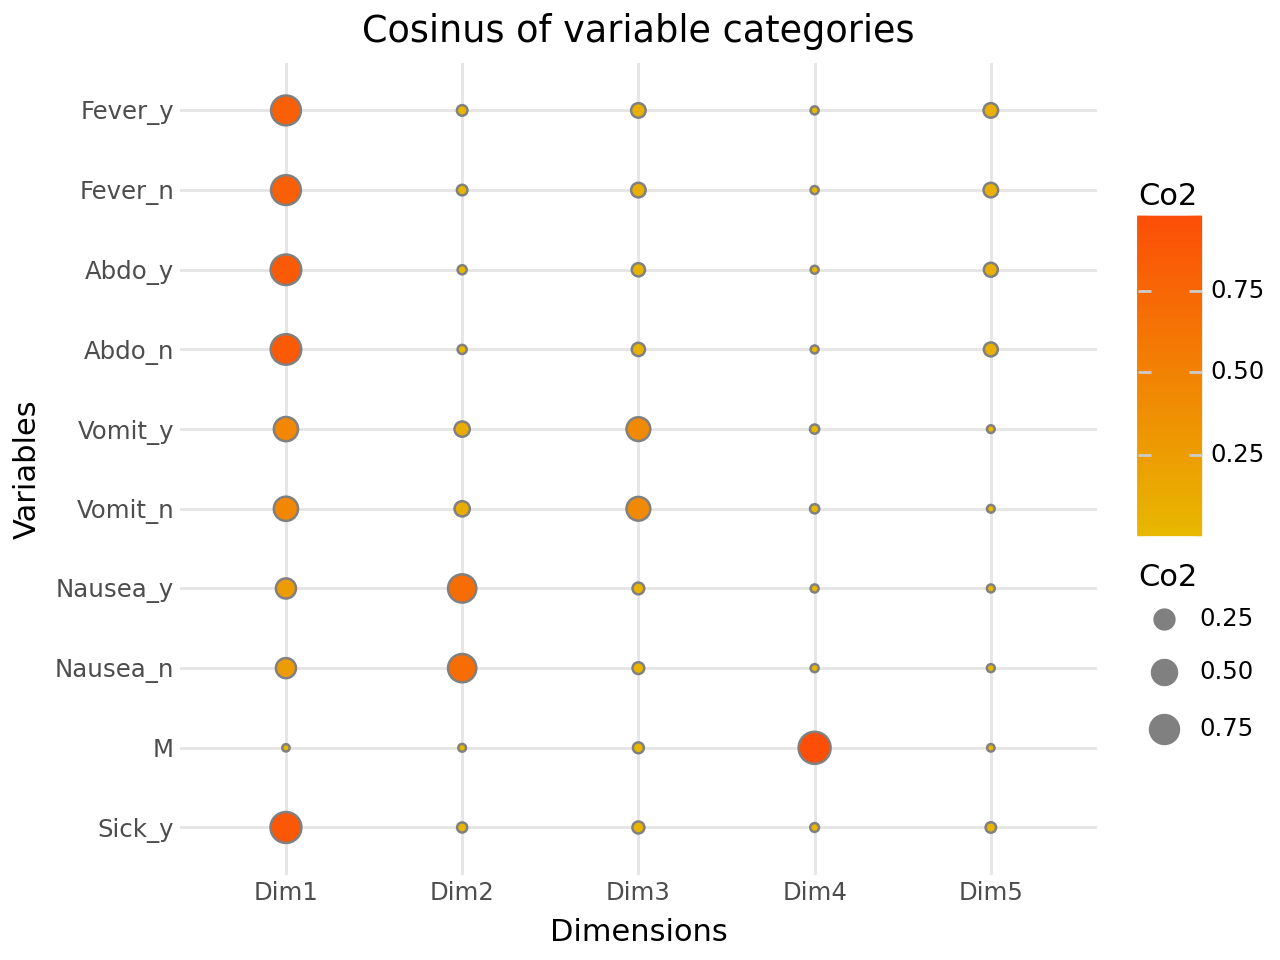

None


In [31]:
# graph of cosinus for variable categories
p = fviz_corrplot(
    X=levels.cos2,
    legend_title="Co2",
    title="Cosinus of variable categories"
)
print(p.show())

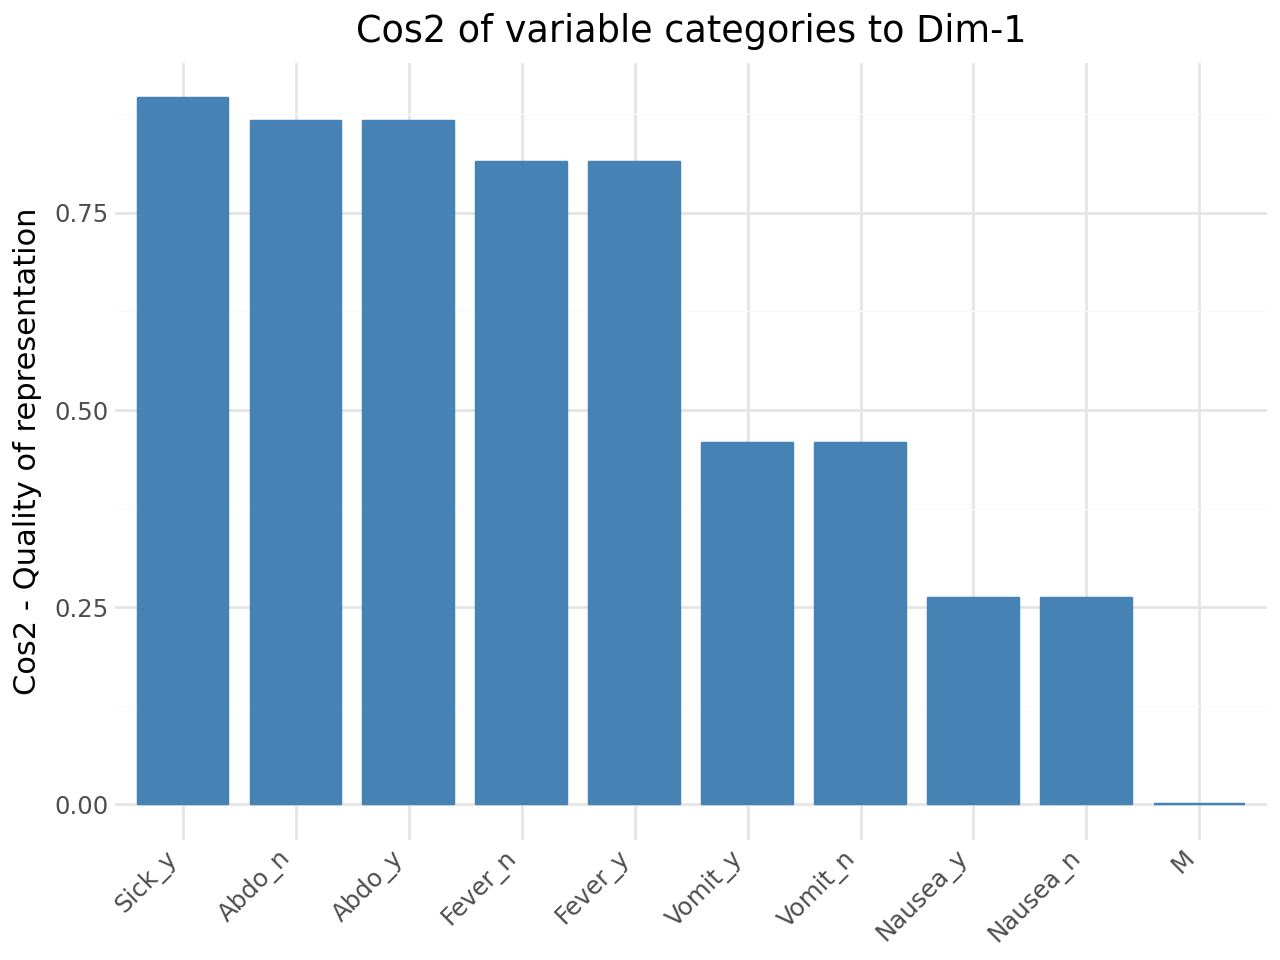

None


In [32]:
# graph of cosinus - levels
p = fviz_cos2(
    obj=clf,
    choice="levels"
)
print(p.show())

### Levels contributions

In [33]:
# levels contributions
levels.contrib

,Dim1,Dim2,Dim3,Dim4,Dim5
Sick_y,10.343195,0.459548,1.707321,0.205711,3.066752
M,0.000007,0.015038,1.663363,98.236823,0.004078
Nausea_n,2.132470,18.494983,1.083831,0.035948,0.070746
Nausea_y,7.641352,66.273688,3.883728,0.128812,0.253507
Vomit_n,6.843842,4.866109,27.728712,0.443513,0.053934
Vomit_y,10.265764,7.299164,41.593068,0.665269,0.080901
Abdo_n,21.766645,0.398640,6.031248,0.075781,29.504948
Abdo_y,10.589179,0.193933,2.934121,0.036866,14.353758
Fever_n,19.356620,1.272025,8.511115,0.108995,33.479966
Fever_y,11.060926,0.726871,4.863494,0.062283,19.131409


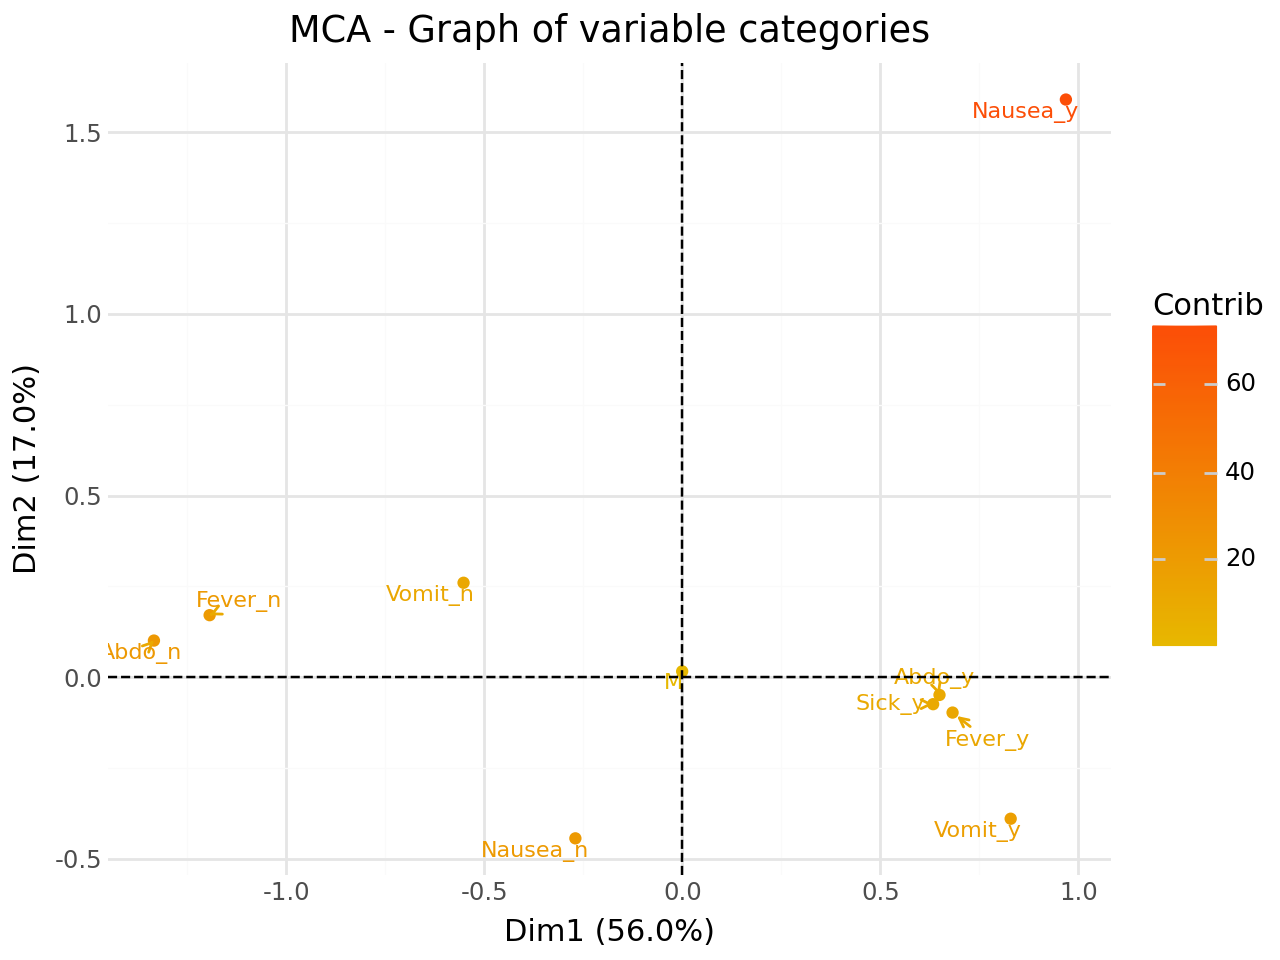

None


In [34]:
# graph of variable categories - color by contributions
p = fviz_mca(
    obj=clf,
    choice="levels",
    col_var = "contrib",
    repel = True,
    quali_sup = False
)
print(p.show())

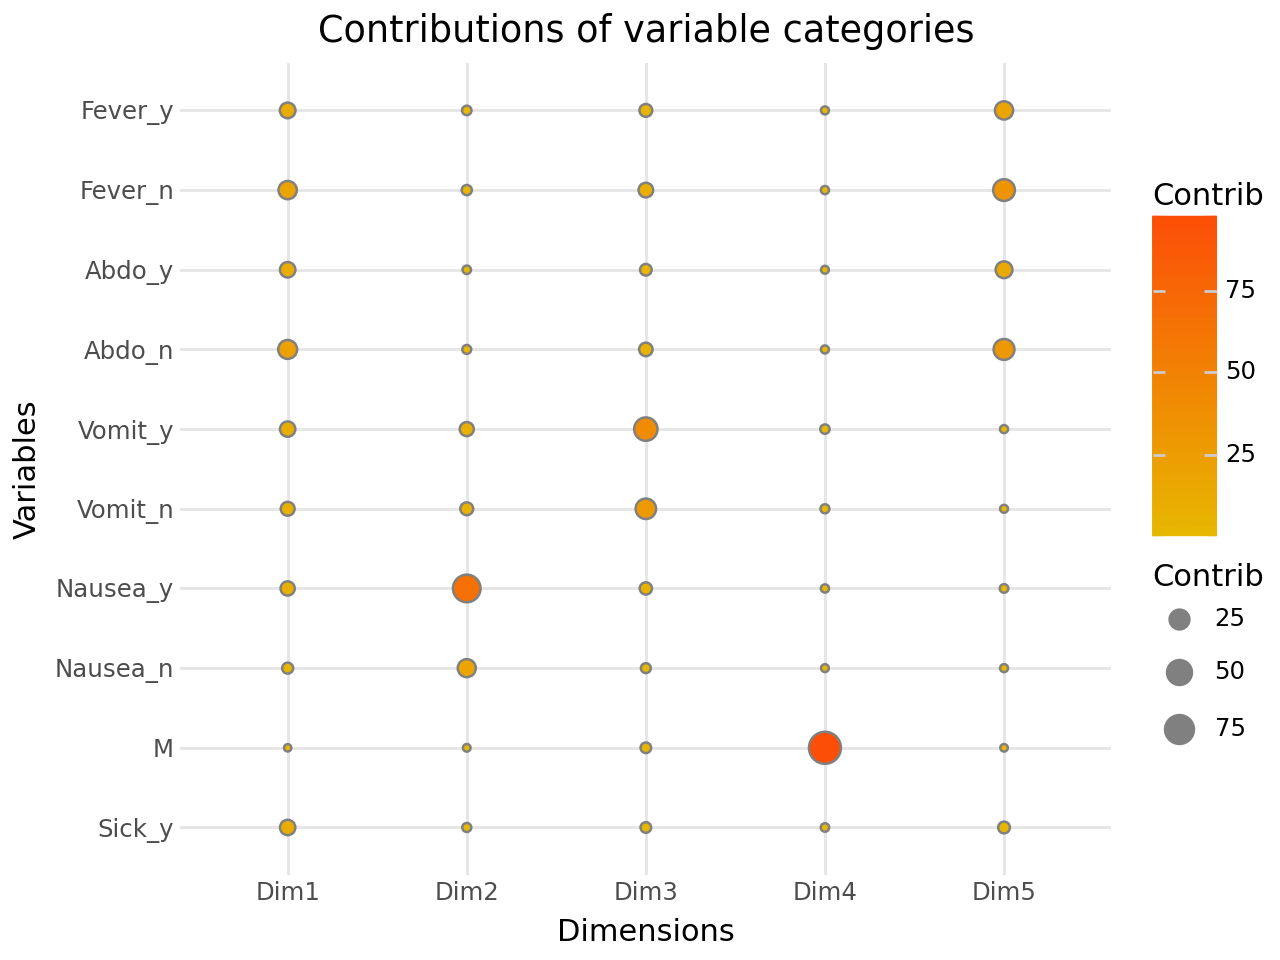

None


In [35]:
# graph of contributions for variable categories
p = fviz_corrplot(
    X=levels.contrib,
    legend_title="Contrib",
    title="Contributions of variable categories"
)
print(p.show())

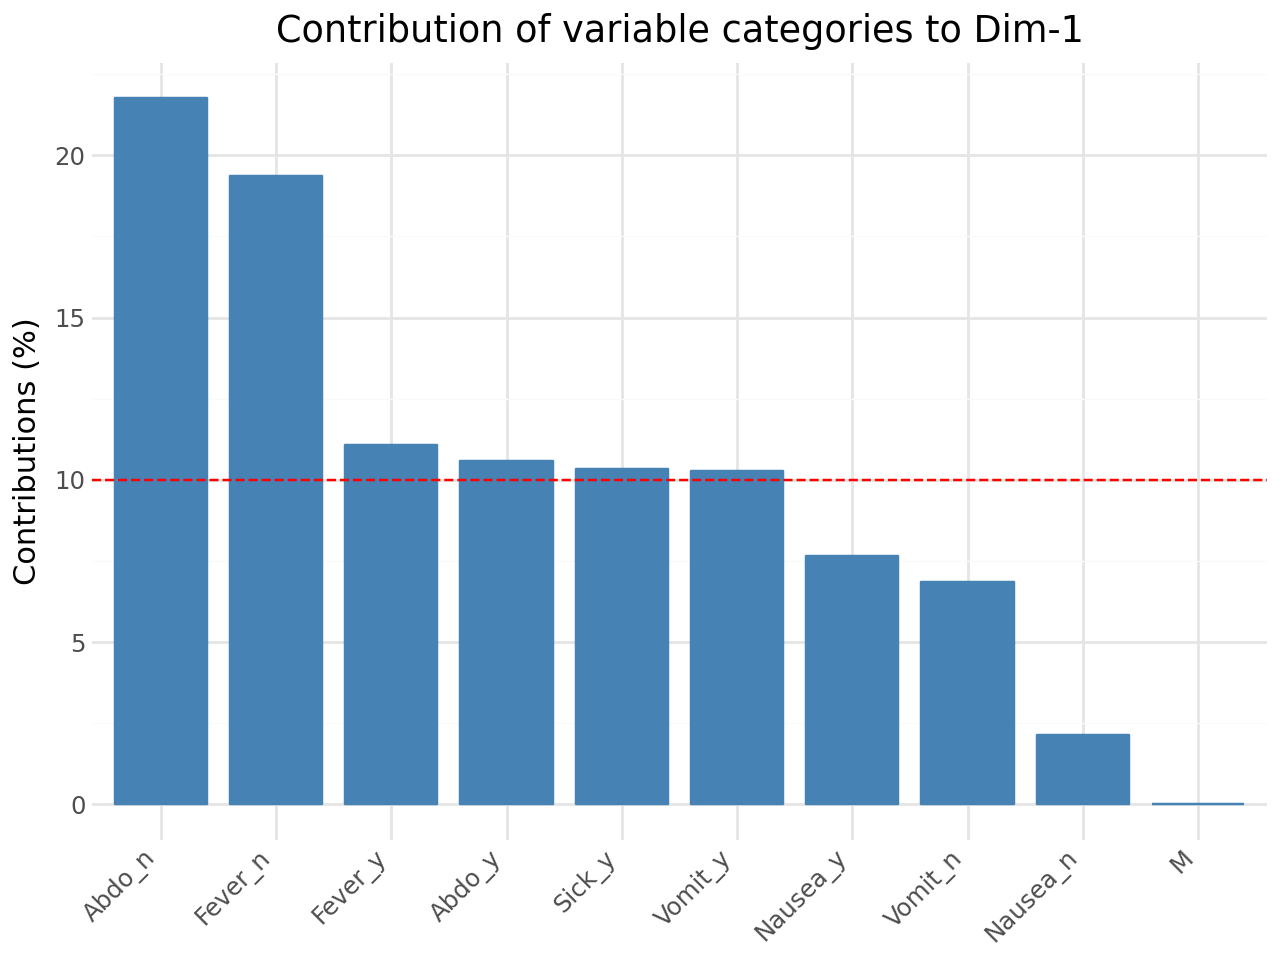

None


In [36]:
# contributions of variable categories to axis 1
p = fviz_contrib(
    obj=clf,
    choice="levels"
)
print(p.show())

### Levels additionals informations

In [37]:
# levels additionals informations
levels.infos

,Proportion,Weight,Sq. Dist.,Inertia,Inertia (%)
Sick_y,0.690909,0.115152,0.447368,0.051515,6.415094
M,0.490909,0.081818,1.037037,0.084848,10.566038
Nausea_n,0.781818,0.130303,0.279070,0.036364,4.528302
Nausea_y,0.218182,0.036364,3.583333,0.130303,16.226415
Vomit_n,0.600000,0.100000,0.666667,0.066667,8.301887
Vomit_y,0.400000,0.066667,1.500000,0.100000,12.452830
Abdo_n,0.327273,0.054545,2.055556,0.112121,13.962264
Abdo_y,0.672727,0.112121,0.486486,0.054545,6.792453
Fever_n,0.363636,0.060606,1.750000,0.106061,13.207547
Fever_y,0.636364,0.106061,0.571429,0.060606,7.547170


## Qualitative variables informations

In [38]:
# qualitative variables informations
quali_var = clf.quali_var_
quali_var._fields

('coord', 'contrib', 'infos')

### Qualitative variables coordinates

In [39]:
# qualitative variables coordinates
quali_var.coord

,Dim1,Dim2,Dim3,Dim4,Dim5
Sick,2.768955e-01,0.003826,0.010709,0.001044,0.004902
Sex,1.809795e-07,0.000125,0.010433,0.498515,0.000007
Nausea,2.616530e-01,0.705835,0.031158,0.000836,0.000518
Vomiting,4.580377e-01,0.101295,0.434803,0.005627,0.000216
Abdominals,8.661910e-01,0.004934,0.056233,0.000572,0.070107
Fever,8.143017e-01,0.016644,0.083889,0.000869,0.084098


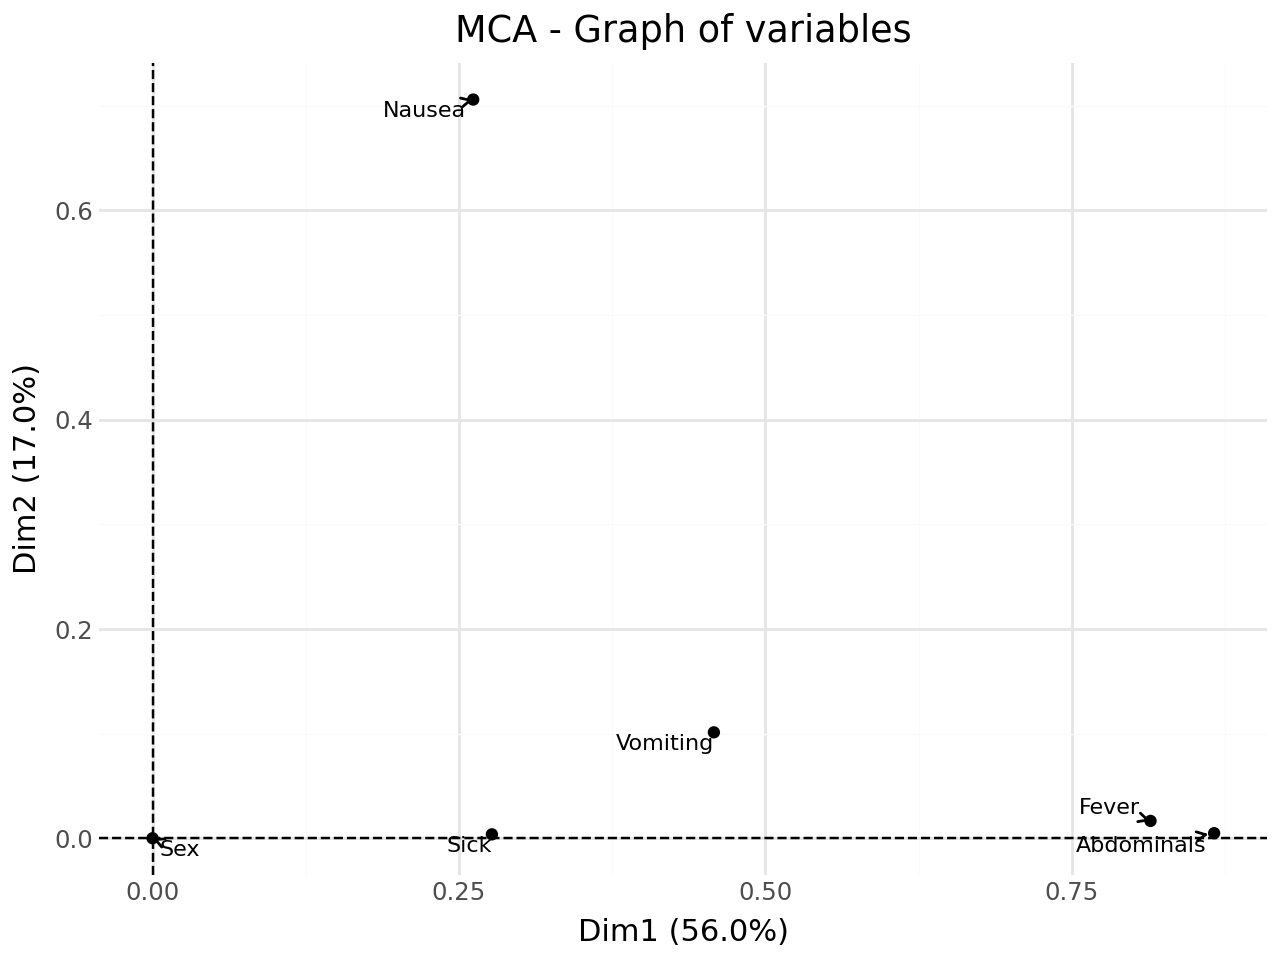

None


In [40]:
# graph of variables
p = fviz_mca(
    obj=clf,
    choice="var",
    repel=True,
    quali_sup = False,
    quanti_sup = False
)
print(p.show())

### Qualitative variables contributions

In [41]:
# qualitative variables contributions
quali_var.contrib

,Dim1,Dim2,Dim3,Dim4,Dim5
Sick,10.343195,0.459548,1.707321,0.205711,3.066752
Sex,0.000007,0.015038,1.663363,98.236823,0.004078
Nausea,9.773823,84.768671,4.967559,0.164760,0.324253
Vomiting,17.109606,12.165273,69.321779,1.108781,0.134835
Abdominals,32.355824,0.592573,8.965368,0.112647,43.858706
Fever,30.417545,1.998896,13.374609,0.171278,52.611375


### Qualitative variables additionals informations

In [42]:
# qualitative variables additionals informations
quali_var.infos

,Weight,Inertia,Inertia (%)
Sick,0.166667,0.051515,6.415094
Sex,0.166667,0.084848,10.566038
Nausea,0.166667,0.166667,20.754717
Vomiting,0.166667,0.166667,20.754717
Abdominals,0.166667,0.166667,20.754717
Fever,0.166667,0.166667,20.754717


## Supplementary quantitative variables informations

In [43]:
# supplementary quantitative variables informations
quanti_var_sup = clf.quanti_var_sup_
quanti_var_sup._fields

('coord', 'cos2', 'dist2')

### Supplementary quantitative variables coordinates

In [44]:
# supplementary quantitatives variables coordinates
quanti_var_sup.coord

,Dim1,Dim2,Dim3,Dim4,Dim5
Age,-0.029597,-0.061137,-0.140093,-0.027418,-0.023389
Time,0.824468,-0.076406,-0.257116,0.071202,0.103862


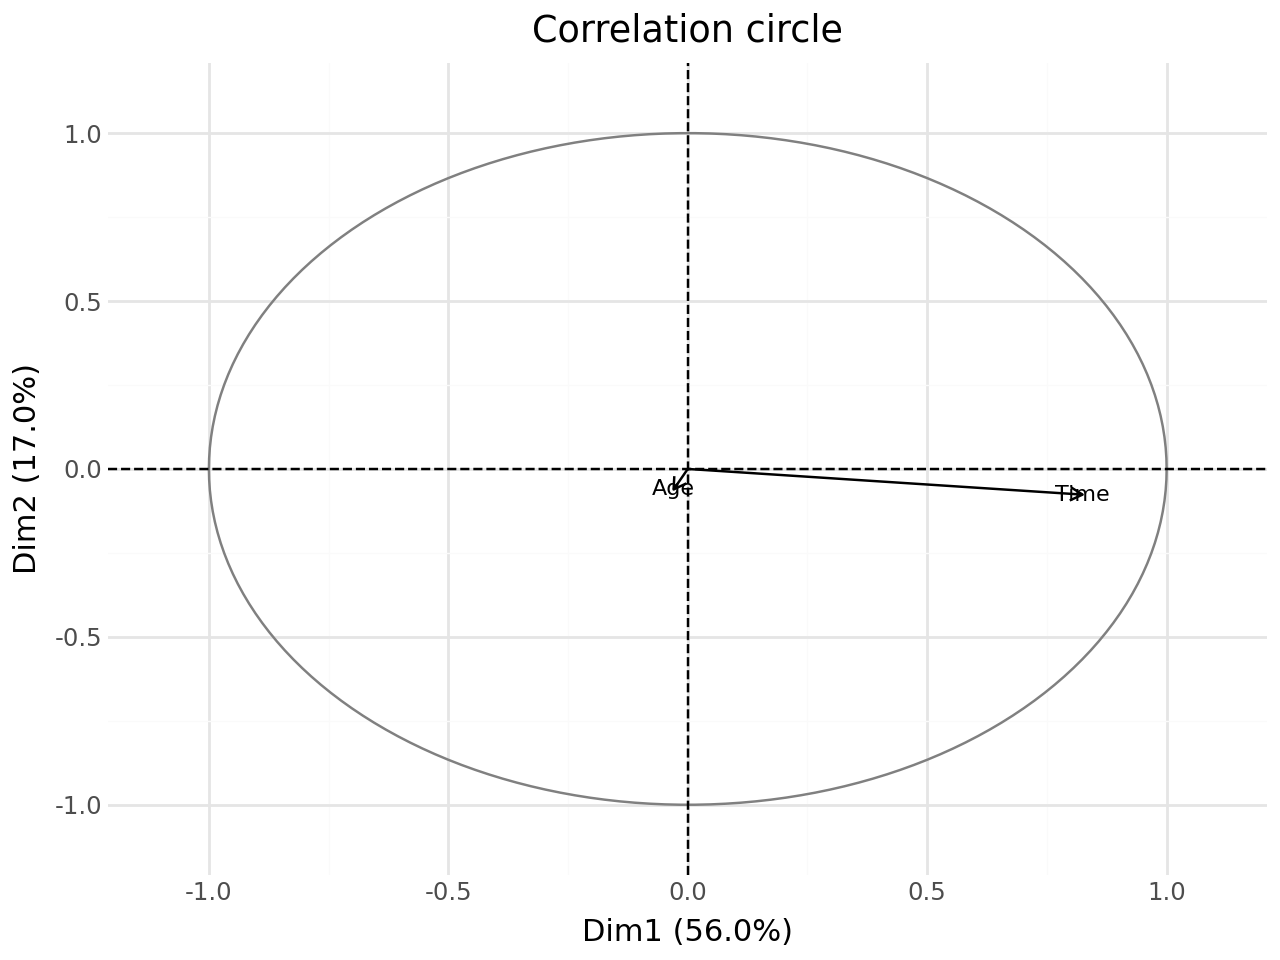

None


In [45]:
# correlation circle
from scientisttools import fviz_corcircle
p = fviz_corcircle(clf)
print(p.show())

### Supplementary quantitative variables cos2

In [46]:
# supplementary quantitative variables cos2
quanti_var_sup.cos2

,Dim1,Dim2,Dim3,Dim4,Dim5
Age,0.000876,0.003738,0.019626,0.000752,0.000547
Time,0.679748,0.005838,0.066109,0.005070,0.010787


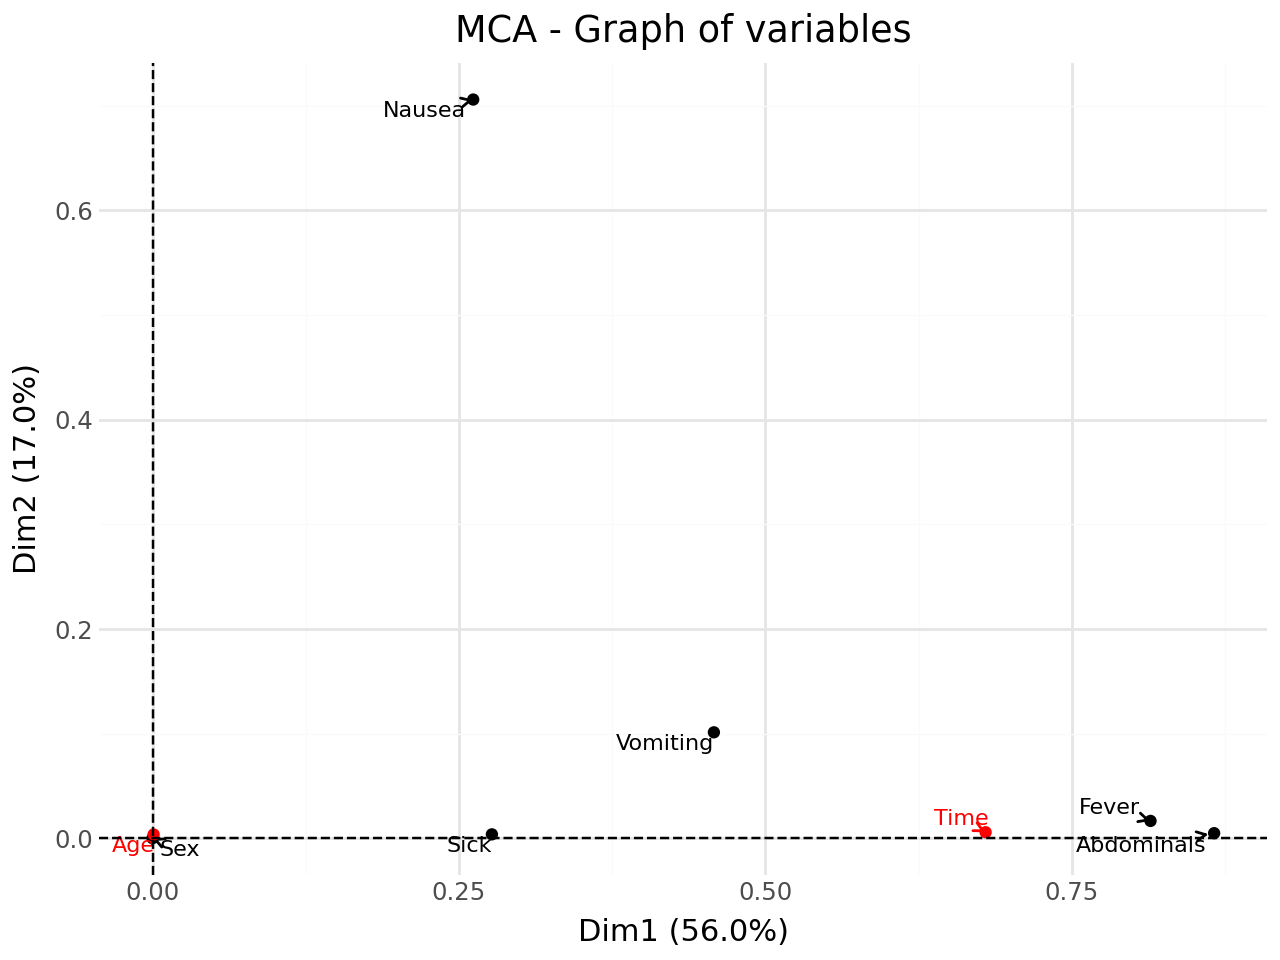

None


In [47]:
# graph of variables with supplementary quantitative variables
p = fviz_mca(
    obj=clf,
    choice="var",
    repel=True,
    quali_sup = False,
    quanti_sup = True
)
print(p.show())

## Supplementary levels informations

In [48]:
# supplementary levels informations
levels_sup = clf.levels_sup_
levels_sup._fields

('coord', 'cos2', 'dist2', 'coord_n', 'vtest')

### Supplementary levels coordinates - Quasi barycenters

In [49]:
# supplementary levels coordinates - quasi barycenters
levels_sup.coord

,Dim1,Dim2,Dim3,Dim4,Dim5
Diarrhea_n,-1.120992,-0.023662,0.348764,-0.134402,0.015500
Diarrhea_y,0.640567,0.013521,-0.199294,0.076801,-0.008857
Potato_n,0.337838,1.314881,-0.866071,0.468033,1.120259
Potato_y,-0.019491,-0.075859,0.049966,-0.027002,-0.064630
Fish_n,0.262913,-0.414749,-1.562838,1.262197,0.085432
Fish_y,-0.004869,0.007681,0.028941,-0.023374,-0.001582
Mayo_n,-1.027863,-0.029359,0.106883,0.000902,-0.150546
Mayo_y,0.228414,0.006524,-0.023752,-0.000200,0.033455
Courg_n,0.432785,-0.443591,0.543575,-0.257811,-0.176997
Courg_y,-0.043278,0.044359,-0.054357,0.025781,0.017700


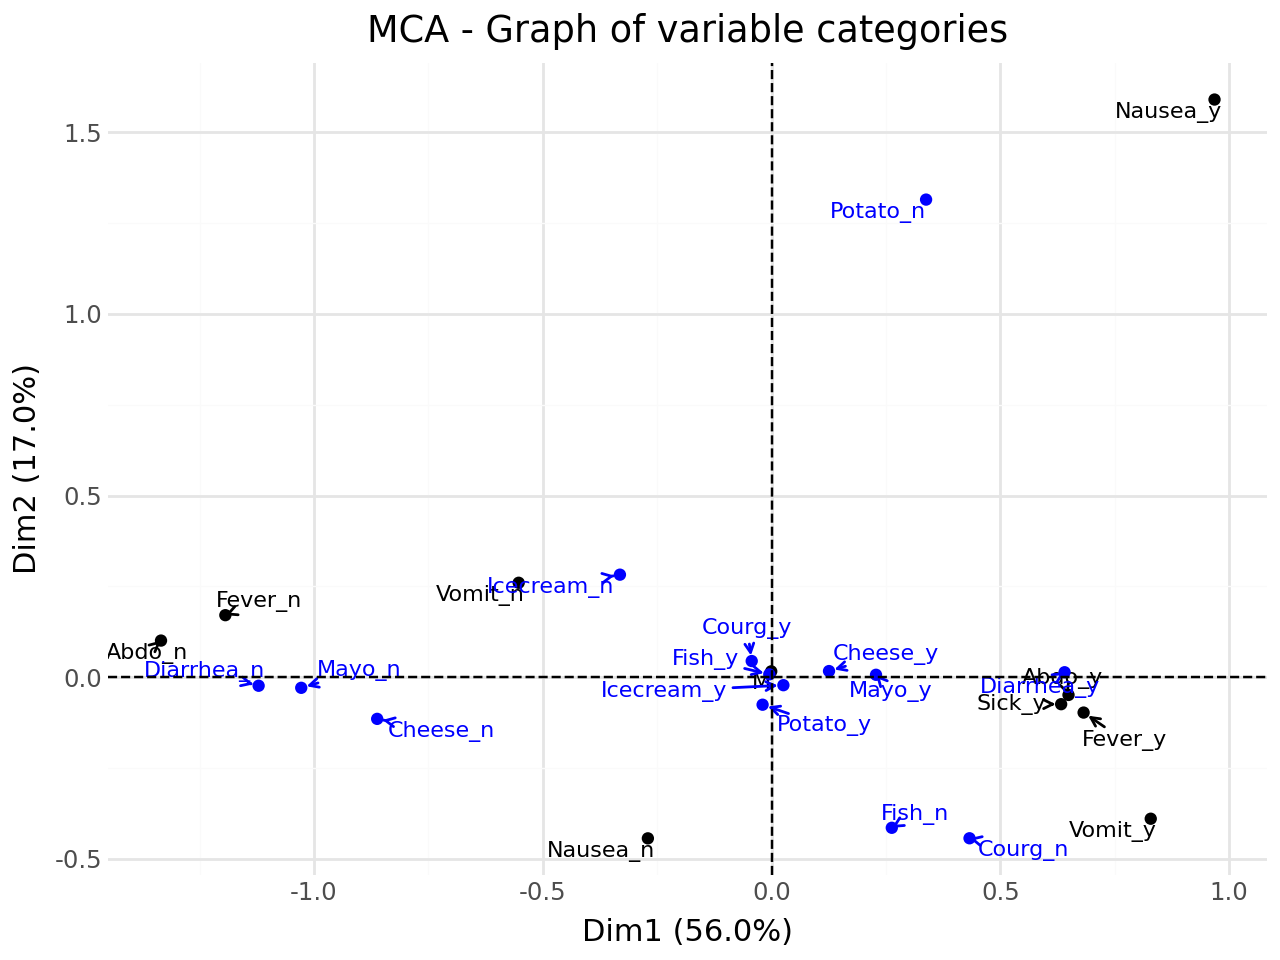

None


In [50]:
# graph of variable categories with supplementary levels
p = fviz_mca(
    obj=clf,
    choice="levels",
    repel = True,
    quali_sup = True
)
print(p.show())

### Supplementary levels coordiates - Barycenters

In [51]:
# supplementary levels coordinates - barycenters
levels_sup.coord_n

,Dim1,Dim2,Dim3,Dim4,Dim5
Diarrhea_n,-0.748785,-0.008815,0.112763,-0.039087,0.002530
Diarrhea_y,0.427877,0.005037,-0.064436,0.022335,-0.001446
Potato_n,0.225665,0.489829,-0.280020,0.136114,0.182850
Potato_y,-0.013019,-0.028259,0.016155,-0.007853,-0.010549
Fish_n,0.175617,-0.154505,-0.505300,0.367074,0.013944
Fish_y,-0.003252,0.002861,0.009357,-0.006798,-0.000258
Mayo_n,-0.686579,-0.010937,0.034558,0.000262,-0.024572
Mayo_y,0.152573,0.002430,-0.007679,-0.000058,0.005461
Courg_n,0.289086,-0.165250,0.175750,-0.074977,-0.028890
Courg_y,-0.028909,0.016525,-0.017575,0.007498,0.002889


### Supplementary vtest

In [52]:
# supplementary levels vtest
levels_sup.vtest

,Dim1,Dim2,Dim3,Dim4,Dim5
Diarrhea_n,-6.227020,-0.131443,1.937357,-0.746590,0.086099
Diarrhea_y,6.227020,0.131443,-1.937357,0.746590,-0.086099
Potato_n,0.596300,2.320824,-1.528654,0.826100,1.977308
Potato_y,-0.596300,-2.320824,1.528654,-0.826100,-1.977308
Fish_n,0.262913,-0.414749,-1.562838,1.262197,0.085432
Fish_y,-0.262913,0.414749,1.562838,-1.262197,-0.085432
Mayo_n,-3.560623,-0.101703,0.370253,0.003125,-0.521507
Mayo_y,3.560623,0.101703,-0.370253,-0.003125,0.521507
Courg_n,1.005701,-1.030811,1.263154,-0.599100,-0.411304
Courg_y,-1.005701,1.030811,-1.263154,0.599100,0.411304


### Supplementary levels cos2

In [53]:
# supplementary levels cos2
levels_sup.cos2

,Dim1,Dim2,Dim3,Dim4,Dim5
Diarrhea_n,0.718070,0.000320,0.069507,1.032217e-02,0.000137
Diarrhea_y,0.718070,0.000320,0.069507,1.032217e-02,0.000137
Potato_n,0.006585,0.099745,0.043274,1.263779e-02,0.072403
Potato_y,0.006585,0.099745,0.043274,1.263779e-02,0.072403
Fish_n,0.001280,0.003185,0.045231,2.950264e-02,0.000135
Fish_y,0.001280,0.003185,0.045231,2.950264e-02,0.000135
Mayo_n,0.234778,0.000192,0.002539,1.808617e-07,0.005036
Mayo_y,0.234778,0.000192,0.002539,1.808617e-07,0.005036
Courg_n,0.018730,0.019677,0.029547,6.646672e-03,0.003133
Courg_y,0.018730,0.019677,0.029547,6.646672e-03,0.003133


### Supplementary levels dist2

In [54]:
# supplementary levels dist2
levels_sup.dist2.to_frame()

,Sq. Dist.
Diarrhea_n,1.750000
Diarrhea_y,0.571429
Potato_n,17.333333
Potato_y,0.057692
Fish_n,54.000000
Fish_y,0.018519
Mayo_n,4.500000
Mayo_y,0.222222
Courg_n,10.000000
Courg_y,0.100000


## Supplementary qualitative variables informations

In [55]:
# supplementary qualitative variables informations
quali_var_sup = clf.quali_var_sup_
quali_var_sup._fields

('coord',)

### Supplementary qualitative variables coordinates

In [56]:
# supplementary qualitative variables coordinates
quali_var_sup.coord

,Dim1,Dim2,Dim3,Dim4,Dim5
Diarrhae,0.718070,0.000320,0.069507,1.032217e-02,0.000137
Potato,0.006585,0.099745,0.043274,1.263779e-02,0.072403
Fish,0.001280,0.003185,0.045231,2.950264e-02,0.000135
Mayo,0.234778,0.000192,0.002539,1.808617e-07,0.005036
Courgette,0.018730,0.019677,0.029547,6.646672e-03,0.003133
Cheese,0.108334,0.001923,0.000028,2.402329e-03,0.002559
Icecream,0.008609,0.006245,0.000182,1.852234e-02,0.002359


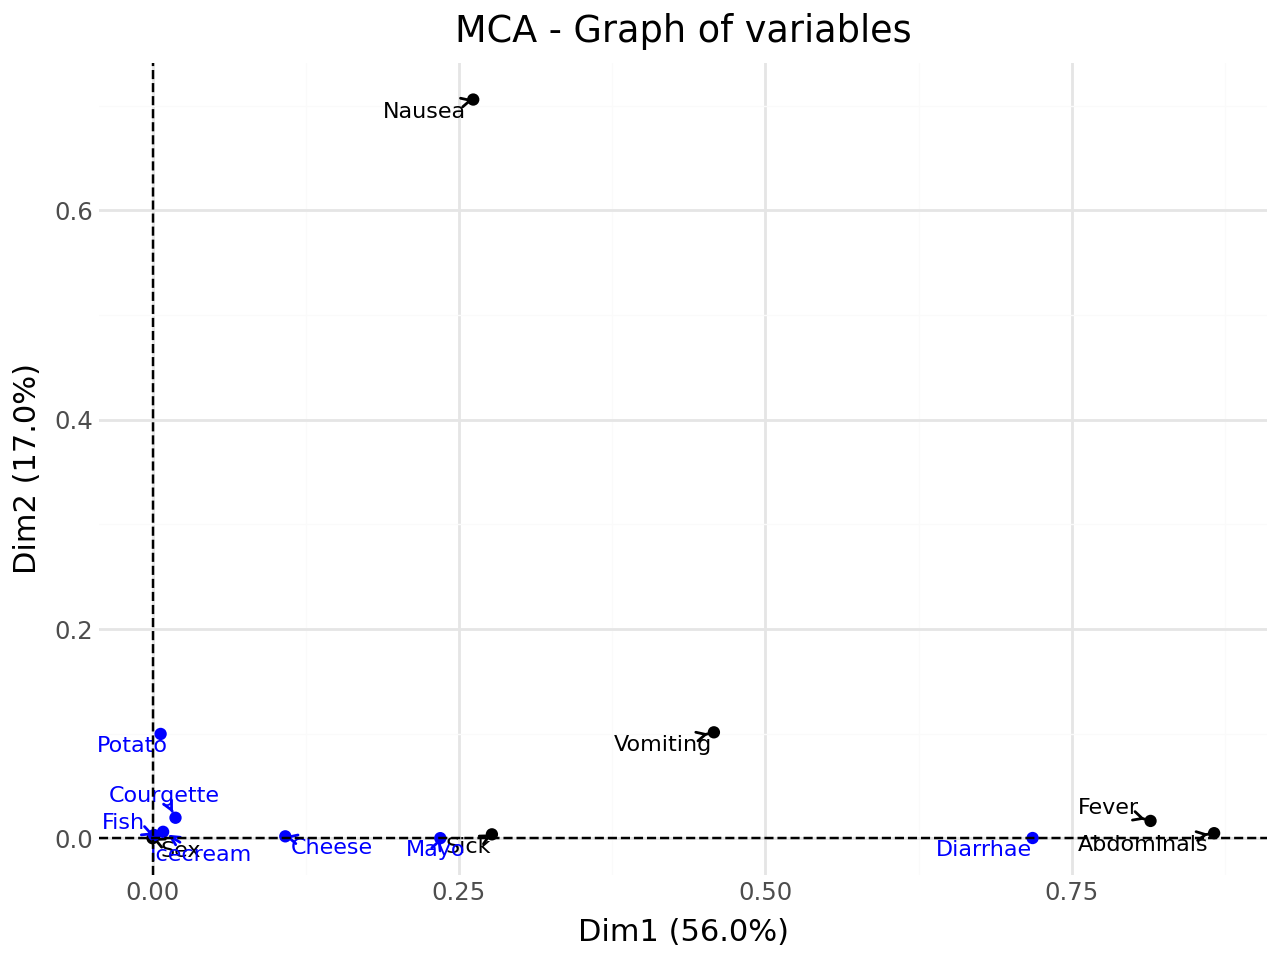

None


In [57]:
# graph of variables with supplementary qualitative variables
p = fviz_mca(
    obj=clf,
    choice="var",
    repel=True,
    quali_sup = True,
    quanti_sup = False
)
print(p.show())

## Others functions

### Ellipses - `fviz_ellipses`

13 [-0.41884018 -0.93654363]
14 [0.06317016 0.05471286]
15 [-0.40967975 -0.24203317]
4 [-0.26208558 -0.84308331]
17 [0.40149331 0.77447291]
11 [ 0.46654336 -0.10337692]
15 [ 0.95994081 -0.06190852]
15 [-0.86275215  0.02623717]
18 [-0.32637486  0.41363259]
21 [0.65701718 0.95986344]
19 [-0.68408366  0.06825444]
30 [ 0.30225244 -0.22049041]
34 [0.63734942 0.88228499]
13 [ 0.31323741 -0.15221253]
16 [-0.43295844 -0.70268771]
23 [ 0.75604337 -0.96093262]
26 [-0.97909138 -0.69983459]
5 [-0.53678518  0.41233123]
8 [-0.20814184 -0.61399356]
30 [ 0.83599823 -0.27556238]
34 [-0.61865213 -0.91369486]
35 [ 0.33946068 -0.07680741]
16 [-0.44757107 -0.00894828]
19 [-0.90309485  0.77014777]
24 [0.3920646  0.89209614]
22 [ 0.59331972 -0.92749676]
32 [-0.41051357 -0.6523465 ]
41 [-0.50923687 -0.54979614]
42 [0.97991509 0.62643648]
13 [0.80837666 0.27898247]
17 [-0.20207735  0.19652147]
21 [ 0.08097668 -0.51835352]
10 [-0.44430989  0.55714844]
20 [-0.26499683 -0.69501159]
34 [ 0.93636984 -0.77997159]
27

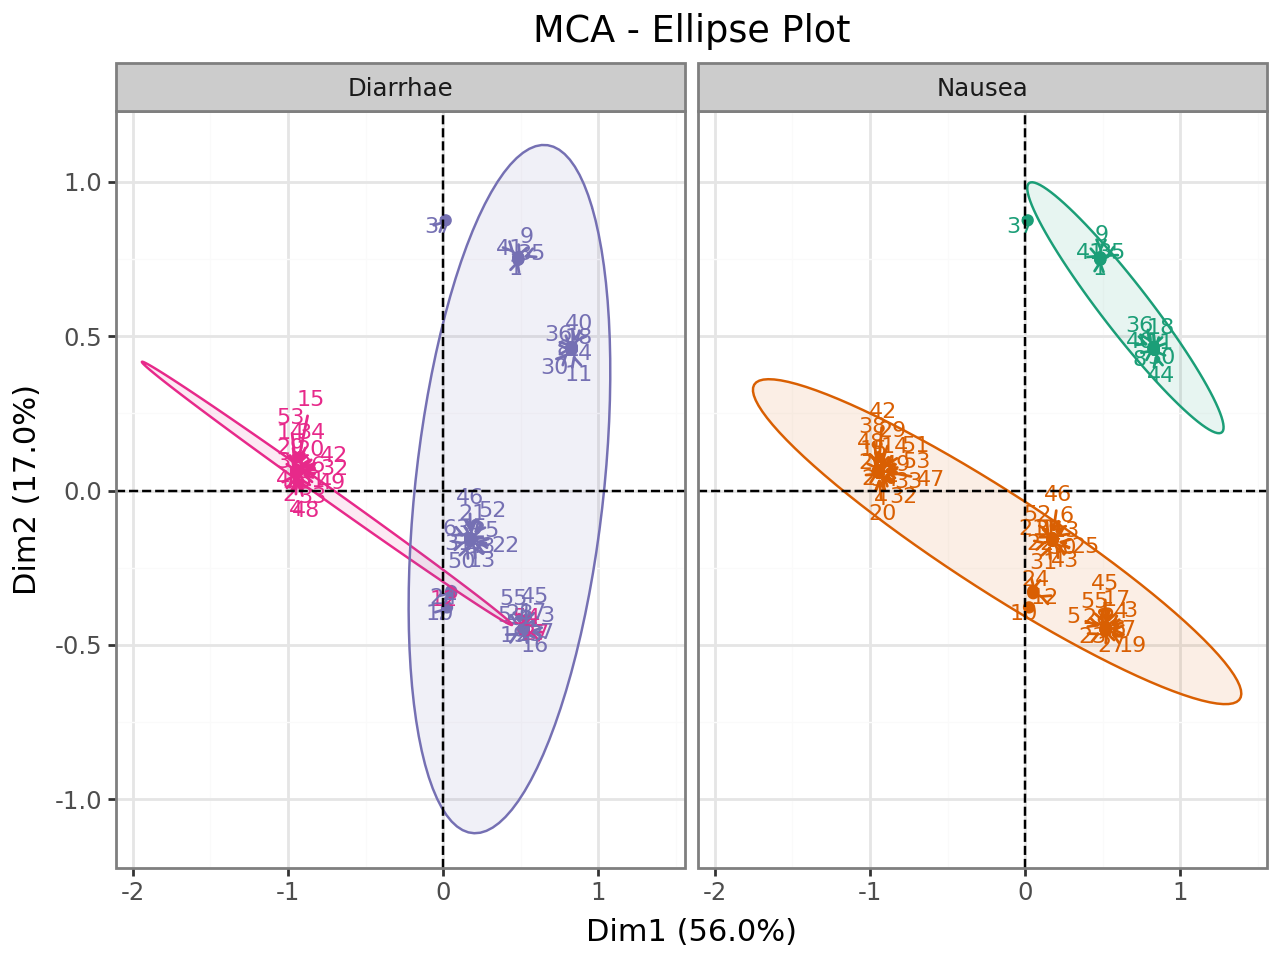

None


In [58]:
# ellipses
from scientisttools import fviz_ellipses
p = fviz_ellipses(
    obj=clf,
    habillage=["Nausea","Diarrhae"],
    repel=True,
    add_ellipses=True
)
print(p.show())

### Summary

In [59]:
# summary
from scientisttools import summary
summary(clf)

                     Multiple Correspondence Analysis - Results                     

Importance of components:
      Eigenvalue  Difference  Proportion (%)  Cumulative (%)  modified rates  \
Dim1      0.4462      0.3074         55.5620         55.5620           100.0   
Dim2      0.1388      0.0342         17.2816         72.8436             0.0   
Dim3      0.1045      0.0200         13.0178         85.8615             0.0   

      cumulative modified rates  
Dim1                      100.0  
Dim2                      100.0  
Dim3                      100.0  

Individuals (the 10 first):
      Dim1    cos2     ctr    Dim2    cos2     ctr    Dim3    cos2     ctr
1   0.4848  0.2375  0.9577  0.7484  0.5661  7.3388 -0.3601  0.1311  2.2558
2  -0.9452  0.9034  3.6403  0.0586  0.0035  0.0450  0.0546  0.0030  0.0519
3   0.5205  0.4689  1.1039 -0.4523  0.3541  2.6803  0.1134  0.0223  0.2236
4  -0.9452  0.9034  3.6403  0.0586  0.0035  0.0450  0.0546  0.0030  0.0519
5   0.5203  0.4637  1.1032 

In [60]:
# formatting text to markdown
summary(clf,to_markdown=True)

                     Multiple Correspondence Analysis - Results                     

Importance of components:
        Eigenvalue    Difference    Proportion (%)    Cumulative (%)    modified rates    cumulative modified rates
----  ------------  ------------  ----------------  ----------------  ----------------  ---------------------------
Dim1        0.4462        0.3074           55.562            55.562                100                          100
Dim2        0.1388        0.0342           17.2816           72.8436                 0                          100
Dim3        0.1045        0.02             13.0178           85.8615                 0                          100

Individuals (the 10 first):
       Dim1    cos2     ctr     Dim2    cos2     ctr     Dim3    cos2     ctr
--  -------  ------  ------  -------  ------  ------  -------  ------  ------
 1   0.4848  0.2375  0.9577   0.7484  0.5661  7.3388  -0.3601  0.1311  2.2558
 2  -0.9452  0.9034  3.6403   0.0586  0.0035 